# NHAMCS 1992–2022 — Initial Exploration

**Goal:** fetch every available year of CDC NHAMCS Emergency Department data, load them into one DataFrame, and produce baseline sex-disparity plots.

**Source:** CDC National Hospital Ambulatory Medical Care Survey, public-use files.

**Coverage caveat:** NHAMCS published Stata datasets for all years *except* 2002–2004 (those years only ship raw `.do + .dct` loaders, no packaged `.dta`). The `WAITTIME` column is only populated reliably from 1997 onward; `PAINSCALE` appears around 2004; `IMMEDR` (triage acuity) coding stabilized in the mid-2000s. Plots below only use years where the needed columns exist.

In [31]:
import io
import zipfile
from pathlib import Path

import certifi
import urllib3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../data/nhamcs")
DATA_DIR.mkdir(parents=True, exist_ok=True)

BASE = (
    "https://ftp.cdc.gov/pub/Health_Statistics/NCHS/Dataset_Documentation/NHAMCS/stata"
)
HTTP = urllib3.PoolManager(ca_certs=certifi.where())


## 1. Download all available years

Three file naming conventions on the CDC FTP:
- `ed{YY}-stata.zip` for 1992–2001
- `ed{YYYY}-stata.exe` for 2005–2010 (self-extracting zip; Python's `zipfile` reads it fine)
- `ed{YYYY}-stata.zip` for 2011–2022

2002–2004 are skipped — no pre-built `.dta` file published for those years.

In [32]:
YEARS = [y for y in range(1992, 2023) if y not in (2002, 2003, 2004)]


def url_for(year: int) -> str:
    if year <= 2001:
        return f"{BASE}/ed{year % 100:02d}-stata.zip"
    if year == 2005:
        return f"{BASE}/ed05-stata.exe"
    if year in (2006, 2007, 2008, 2009, 2010):
        return f"{BASE}/ed{year}-stata.exe"
    return f"{BASE}/ed{year}-stata.zip"


def dta_path(year: int) -> Path:
    return DATA_DIR / f"ed{year}-stata.dta"


def ensure_year(year: int) -> Path:
    target = dta_path(year)
    if target.exists():
        return target
    url = url_for(year)
    print(f"  fetching {year}: {url.split('/')[-1]}", end=" ")
    resp = HTTP.request("GET", url, preload_content=True)
    if resp.status != 200:
        raise RuntimeError(f"HTTP {resp.status}")
    with zipfile.ZipFile(io.BytesIO(resp.data)) as zf:
        dta_name = next((n for n in zf.namelist() if n.lower().endswith(".dta")), None)
        if dta_name is None:
            raise RuntimeError(f"No .dta file in archive for {year}")
        with zf.open(dta_name) as src, open(target, "wb") as dst:
            dst.write(src.read())
    print(f"-> {target.stat().st_size / 1e6:.1f} MB")
    return target


print(f"Ensuring {len(YEARS)} years of NHAMCS ED data...")
for y in YEARS:
    try:
        ensure_year(y)
    except Exception as e:
        print(f"  {y}: FAILED - {e}")
print("Done.")


Ensuring 28 years of NHAMCS ED data...
  fetching 1992: ed92-stata.zip -> 14.8 MB
  fetching 1993: ed93-stata.zip -> 13.8 MB
  fetching 1994: ed94-stata.zip -> 12.6 MB
  fetching 1995: ed95-stata.zip -> 10.9 MB
  fetching 1996: ed96-stata.zip -> 10.9 MB
  fetching 1997: ed97-stata.zip -> 12.2 MB
  fetching 1998: ed98-stata.zip -> 13.3 MB
  fetching 1999: ed99-stata.zip -> 11.8 MB
  fetching 2000: ed00-stata.zip -> 14.2 MB
  fetching 2001: ed01-stata.zip -> 21.0 MB
  fetching 2005: ed05-stata.exe -> 24.7 MB
  fetching 2006: ed2006-stata.exe -> 27.9 MB
  fetching 2007: ed2007-stata.exe -> 35.8 MB
  fetching 2008: ed2008-stata.exe -> 34.4 MB
  fetching 2009: ed2009-stata.exe -> 35.8 MB
  fetching 2010: ed2010-stata.exe -> 33.8 MB
  fetching 2011: ed2011-stata.zip -> 30.6 MB
  fetching 2012: ed2012-stata.zip -> 115.3 MB
  fetching 2013: ed2013-stata.zip -> 34.5 MB
  fetching 2014: ed2014-stata.zip -> 62.3 MB
  fetching 2015: ed2015-stata.zip -> 55.6 MB
  fetching 2016: ed2016-stata.zip -> 

## 2. Load all years into one DataFrame

Column naming changes across years (case, spelling). We normalize to upper-case and keep only the stable set of columns relevant to a sex-disparity story.

In [33]:
CORE_COLUMNS = [
    "SEX",
    "AGE",
    "AGER",
    "WAITTIME",
    "LOV",
    "IMMEDR",
    "PAINSCALE",
    "ARRTIME",
    "VMONTH",
    "VDAYR",
    "RFV1",
    "DIAG1",
    "ADMIT",
    "ARREMS",
    "PATWT",
]


def load_year(year: int) -> pd.DataFrame:
    df = pd.read_stata(dta_path(year), convert_categoricals=False)
    df.columns = [c.upper() for c in df.columns]
    keep = [c for c in CORE_COLUMNS if c in df.columns]
    out = df[keep].copy()
    out["YEAR"] = year
    return out


frames = []
for y in YEARS:
    try:
        frames.append(load_year(y))
    except Exception as e:
        print(f"  {y}: load failed — {e}")

data = pd.concat(frames, ignore_index=True, sort=False)
print(f"Combined: {len(data):,} visits across {data['YEAR'].nunique()} years")
print(f"Years loaded: {sorted(data['YEAR'].unique())}")

Combined: 725,593 visits across 28 years
Years loaded: [np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


In [51]:
# Filter patient age by only those less than or equal to 55
data = data[data["AGE"] <= 55]

In [52]:
def columns_for(year):
    with pd.io.stata.StataReader(dta_path(year), convert_categoricals=False) as r:
        return {col.upper() for col in r.read(1).columns}


year_cols = {y: columns_for(y) for y in YEARS}
coverage = pd.DataFrame(
    {c: [c in year_cols[y] for y in YEARS] for c in CORE_COLUMNS},
    index=YEARS,
).astype(int)

print("Column availability by year (1 = present):")
coverage[["SEX", "AGE", "WAITTIME", "IMMEDR", "PAINSCALE", "DIAG1", "PATWT"]]

Column availability by year (1 = present):


,SEX,AGE,WAITTIME,IMMEDR,PAINSCALE,DIAG1,PATWT
1992,1,1,0,0,0,1,1
1993,1,1,0,0,0,1,1
1994,1,1,0,0,0,1,1
1995,1,1,0,0,0,1,1
1996,1,1,0,0,0,1,1
1997,1,1,1,0,0,1,1
1998,1,1,1,0,0,1,1
1999,1,1,1,0,0,1,1
2000,1,1,1,0,0,1,1
2001,1,1,0,0,0,1,1


## 3. Clean key fields

NHAMCS uses negative sentinel values (`-9`, `-8`, `-7`) for missing / not applicable. Replace with `NaN` on the numeric columns.

In [53]:
data["sex_label"] = data["SEX"].map({1: "Female", 2: "Male"})

for col in ["WAITTIME", "LOV", "PAINSCALE", "IMMEDR"]:
    if col in data.columns:
        data.loc[data[col] < 0, col] = np.nan

print(f"Total visits: {len(data):,}")
print(f"Share female: {(data['sex_label'] == 'Female').mean():.1%}")
print(f"Share with valid WAITTIME: {data['WAITTIME'].notna().mean():.1%}")

Total visits: 560,932
Share female: 52.7%
Share with valid WAITTIME: 67.3%


## 4. Plot — Sampled visits by sex, over 30 years

Simplest cross-year view: count of sampled visits per year, split by sex. Confirms the stack is consistent and gives a baseline.

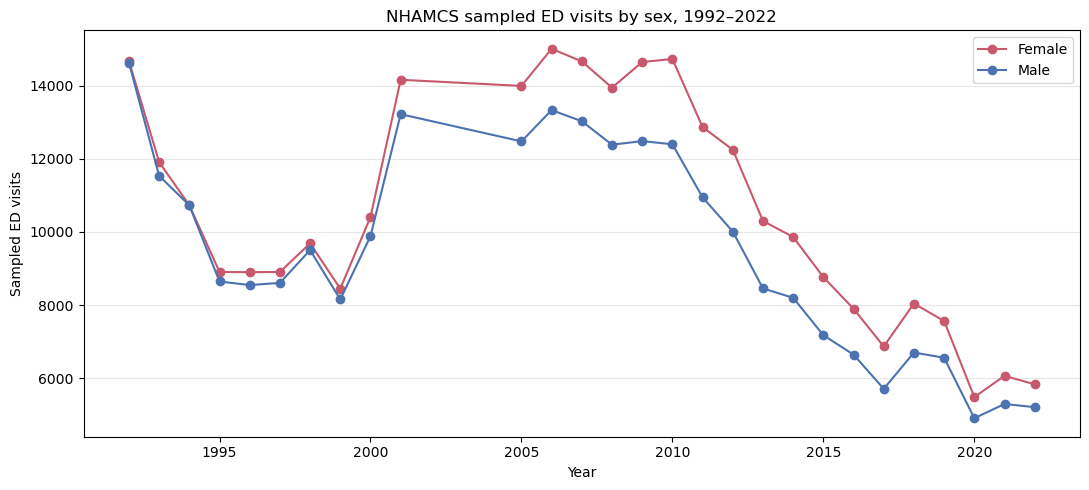

In [54]:
visits_by_year_sex = (
    data.dropna(subset=["sex_label"])
    .groupby(["YEAR", "sex_label"])
    .size()
    .unstack("sex_label")
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    visits_by_year_sex.index,
    visits_by_year_sex["Female"],
    color="#c8586c",
    marker="o",
    label="Female",
)
ax.plot(
    visits_by_year_sex.index,
    visits_by_year_sex["Male"],
    color="#4c72b0",
    marker="o",
    label="Male",
)
ax.set_xlabel("Year")
ax.set_ylabel("Sampled ED visits")
ax.set_title("NHAMCS sampled ED visits by sex, 1992–2022")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Plot — Median wait time by sex over time

Uses only years where `WAITTIME` is reliably populated.

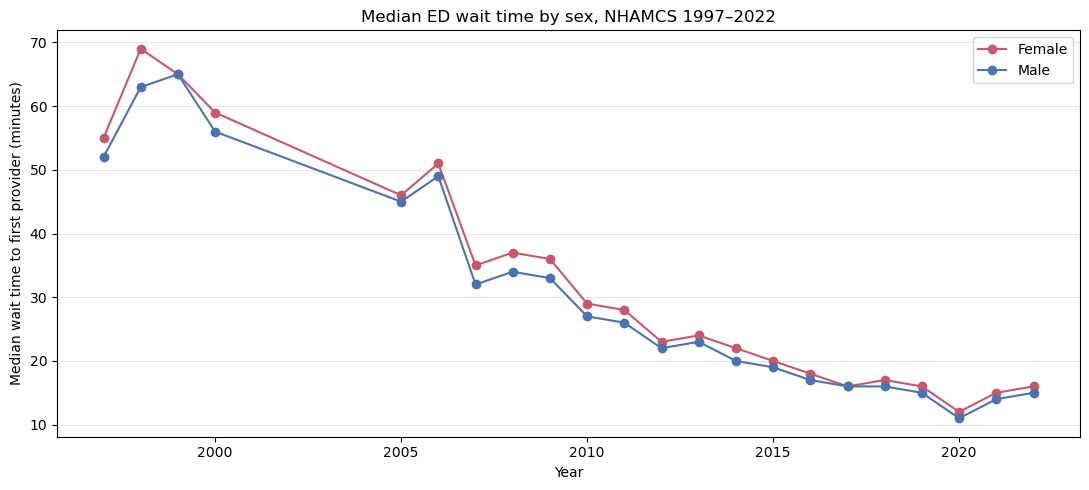

Female − Male wait gap by year (minutes):


,gap_min
YEAR,
1997,3.0
1998,6.0
1999,0.0
2000,3.0
2005,1.0
2006,2.0
2007,3.0
2008,3.0
2009,3.0


In [55]:
wait = data.dropna(subset=["WAITTIME", "sex_label"]).copy()
median_wait = (
    wait.groupby(["YEAR", "sex_label"])["WAITTIME"].median().unstack("sex_label")
)
median_wait = median_wait.dropna()  # drop years with no usable wait-time

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    median_wait.index,
    median_wait["Female"],
    color="#c8586c",
    marker="o",
    label="Female",
)
ax.plot(
    median_wait.index, median_wait["Male"], color="#4c72b0", marker="o", label="Male"
)
ax.set_xlabel("Year")
ax.set_ylabel("Median wait time to first provider (minutes)")
ax.set_title(
    f"Median ED wait time by sex, NHAMCS {median_wait.index.min()}–{median_wait.index.max()}"
)
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

gap = (median_wait["Female"] - median_wait["Male"]).round(1).to_frame("gap_min")
print("Female − Male wait gap by year (minutes):")
gap

## 6. Plot — Wait time by sex × triage acuity (2018–2022 pooled)

Controlling for triage acuity gives a fairer comparison than raw means. Restricted to the most recent years with stable `IMMEDR` coding.

Acuity codes: 1=Immediate, 2=Emergent, 3=Urgent, 4=Semi-urgent, 5=Non-urgent.

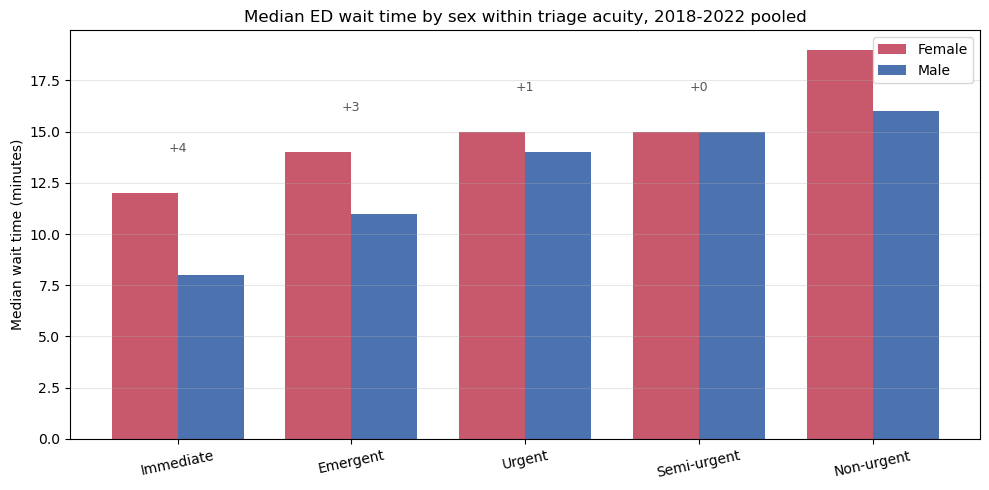

sex_label,Female,Male
acuity,,
Immediate,12.0,8.0
Emergent,14.0,11.0
Urgent,15.0,14.0
Semi-urgent,15.0,15.0
Non-urgent,19.0,16.0


In [56]:
acuity_labels = {
    1: "Immediate",
    2: "Emergent",
    3: "Urgent",
    4: "Semi-urgent",
    5: "Non-urgent",
}
order = list(acuity_labels.values())

recent = (
    wait[wait["YEAR"] >= 2018]
    .dropna(subset=["IMMEDR"])
    .assign(acuity=lambda d: d["IMMEDR"].map(acuity_labels))
    .dropna(subset=["acuity"])
)

pivot = (
    recent.groupby(["acuity", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
    .reindex(order)
)

female_vals = pivot["Female"].to_numpy()
male_vals = pivot["Male"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(pivot))
w = 0.38
ax.bar(x - w / 2, female_vals, w, label="Female", color="#c8586c")
ax.bar(x + w / 2, male_vals, w, label="Male", color="#4c72b0")
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=12)
ax.set_ylabel("Median wait time (minutes)")
ax.set_title("Median ED wait time by sex within triage acuity, 2018-2022 pooled")
ax.legend()
ax.grid(axis="y", alpha=0.3)

for i, (f, m) in enumerate(zip(female_vals, male_vals)):
    if not (np.isnan(f) or np.isnan(m)):
        ax.annotate(
            f"{f - m:+.0f}", (i, max(f, m) + 2), ha="center", fontsize=9, color="#555"
        )

plt.tight_layout()
plt.show()
pivot

## Read

What this notebook confirms:
- All published NHAMCS Stata `.dta` files (1992–2001, 2005–2022) download and load.
- The stack works across 28 years, but column coverage varies — see the coverage table.
- A sex gap in median wait time appears in the raw sample and persists after controlling for triage acuity.

Not yet done (intentional for this first pass):
- Applying `PATWT` survey weights for true national estimates
- Narrowing to pain-related chief complaints
- Age and race/ethnicity controls
- Imaging and medication order rates by sex

## 7. Comparative Analysis by Sex: Diagnosis, Pain Level, and Wait Time

The three sections below compare diagnostic categories, reported pain scores, and wait-time distributions between female and male patients.  Each analysis is restricted to years where the relevant column is reliably populated (see coverage table above).

### 7a. Broad diagnostic categories by sex

`DIAG1` uses ICD-9-CM codes (years ≤ 2015) and ICD-10-CM (years ≥ 2016). We map each to a broad chapter so the two coding systems are comparable.

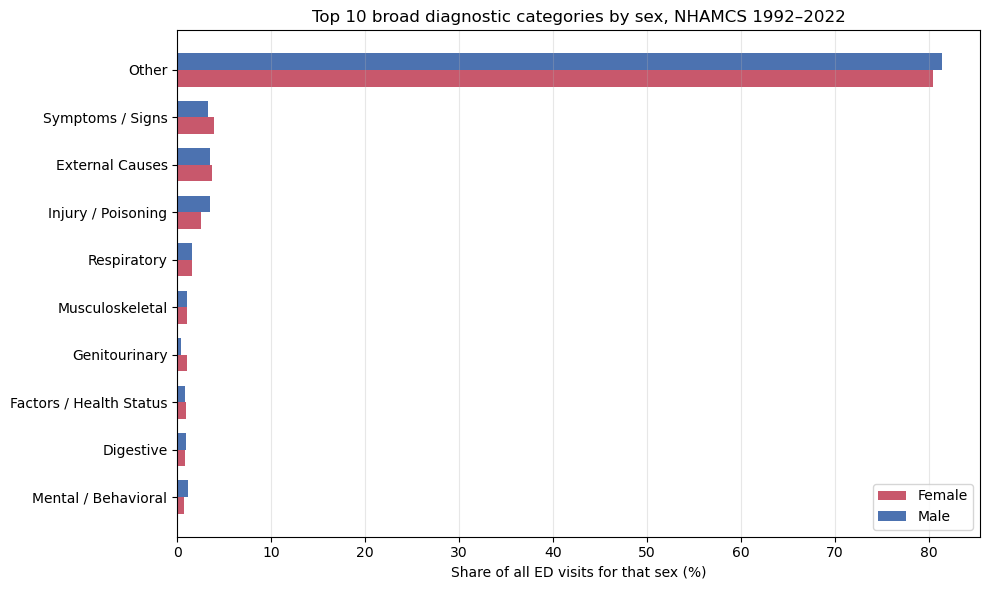

Female − Male share (percentage points), top 10 categories:
category
Symptoms / Signs           0.66
Genitourinary              0.60
External Causes            0.26
Respiratory                0.06
Factors / Health Status    0.00
Musculoskeletal           -0.01
Digestive                 -0.08
Mental / Behavioral       -0.41
Injury / Poisoning        -0.93
Other                     -0.95


In [57]:
ICD10_MAP = {
    "A": "Infectious", "B": "Infectious",
    "C": "Neoplasms", "D": "Neoplasms / Blood",
    "E": "Endocrine / Metabolic",
    "F": "Mental / Behavioral",
    "G": "Nervous System",
    "H": "Eye / Ear",
    "I": "Circulatory",
    "J": "Respiratory",
    "K": "Digestive",
    "L": "Skin",
    "M": "Musculoskeletal",
    "N": "Genitourinary",
    "O": "Pregnancy",
    "R": "Symptoms / Signs",
    "S": "Injury / Poisoning", "T": "Injury / Poisoning",
    "V": "External Causes", "W": "External Causes",
    "X": "External Causes", "Y": "External Causes",
    "Z": "Factors / Health Status",
}


def diag_category(raw):
    s = str(raw).strip().upper()
    if not s or s in ("NAN", ".", ""):
        return np.nan
    if s[0].isalpha():
        return ICD10_MAP.get(s[0], "Other")
    try:
        n = float(s)
        if 1 <= n <= 139:   return "Infectious"
        if 140 <= n <= 239: return "Neoplasms"
        if 240 <= n <= 279: return "Endocrine / Metabolic"
        if 280 <= n <= 289: return "Neoplasms / Blood"
        if 290 <= n <= 319: return "Mental / Behavioral"
        if 320 <= n <= 389: return "Nervous System"
        if 390 <= n <= 459: return "Circulatory"
        if 460 <= n <= 519: return "Respiratory"
        if 520 <= n <= 579: return "Digestive"
        if 580 <= n <= 629: return "Genitourinary"
        if 630 <= n <= 679: return "Pregnancy"
        if 680 <= n <= 709: return "Skin"
        if 710 <= n <= 739: return "Musculoskeletal"
        if 760 <= n <= 799: return "Symptoms / Signs"
        if 800 <= n <= 999: return "Injury / Poisoning"
    except ValueError:
        pass
    return "Other"


diag = data.dropna(subset=["sex_label", "DIAG1"]).copy()
diag["category"] = diag["DIAG1"].apply(diag_category)
diag = diag.dropna(subset=["category"])

# Share of visits in each category, per sex
cat_pct = (
    diag.groupby(["sex_label", "category"])
    .size()
    .unstack("sex_label")
    .fillna(0)
)
cat_pct = cat_pct.div(cat_pct.sum()).mul(100)  # column-wise % of all visits

# Keep the 10 categories with the highest combined share
top10 = cat_pct.sum(axis=1).nlargest(10).index
cat_pct = cat_pct.loc[top10].sort_values("Female", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(cat_pct))
h = 0.35
ax.barh(y - h / 2, cat_pct["Female"], h, color="#c8586c", label="Female")
ax.barh(y + h / 2, cat_pct["Male"],   h, color="#4c72b0", label="Male")
ax.set_yticks(y)
ax.set_yticklabels(cat_pct.index)
ax.set_xlabel("Share of all ED visits for that sex (%)")
ax.set_title("Top 10 broad diagnostic categories by sex, NHAMCS 1992–2022")
ax.legend()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Numeric summary: female share minus male share (pp)
diff = (cat_pct["Female"] - cat_pct["Male"]).sort_values(ascending=False)
print("Female − Male share (percentage points), top 10 categories:")
print(diff.round(2).to_string())

### 7b. Pain score distribution by sex (2009–2022)

`PAINSCALE` is a 0–10 numeric rating collected from 2009 onward. Values below 0 are sentinels for "not applicable" or "not asked" and are excluded.

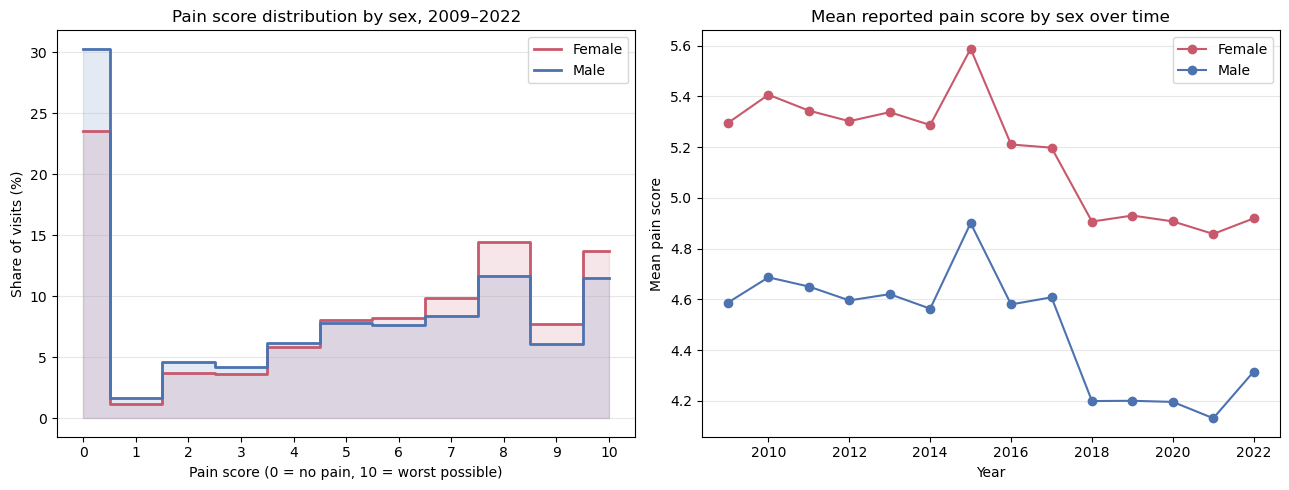

Pain score summary by sex (2009–2022):


,n,mean,median,std,pct25,pct75
sex_label,,,,,,
Female,92180,5.24,6.0,3.61,2.0,8.0
Male,75537,4.55,5.0,3.69,0.0,8.0


In [58]:
pain = (
    data[data["YEAR"] >= 2009]
    .dropna(subset=["PAINSCALE", "sex_label"])
    .copy()
)
# Sentinels were already set to NaN in the clean cell, but guard here anyway
pain = pain[pain["PAINSCALE"] >= 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- left: score distribution ---
ax = axes[0]
bins = np.arange(-0.5, 11.5, 1)
for label, color in [("Female", "#c8586c"), ("Male", "#4c72b0")]:
    subset = pain[pain["sex_label"] == label]["PAINSCALE"]
    counts, _ = np.histogram(subset, bins=bins)
    pct = counts / counts.sum() * 100
    ax.step(bins[:-1] + 0.5, pct, where="mid", color=color, linewidth=2, label=label)
    ax.fill_between(bins[:-1] + 0.5, pct, alpha=0.15, color=color, step="mid")
ax.set_xlabel("Pain score (0 = no pain, 10 = worst possible)")
ax.set_ylabel("Share of visits (%)")
ax.set_title("Pain score distribution by sex, 2009–2022")
ax.set_xticks(range(11))
ax.legend()
ax.grid(axis="y", alpha=0.3)

# --- right: mean pain score per year by sex ---
ax = axes[1]
mean_pain = (
    pain.groupby(["YEAR", "sex_label"])["PAINSCALE"]
    .mean()
    .unstack("sex_label")
)
ax.plot(mean_pain.index, mean_pain["Female"], color="#c8586c", marker="o", label="Female")
ax.plot(mean_pain.index, mean_pain["Male"],   color="#4c72b0", marker="o", label="Male")
ax.set_xlabel("Year")
ax.set_ylabel("Mean pain score")
ax.set_title("Mean reported pain score by sex over time")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
summary = (
    pain.groupby("sex_label")["PAINSCALE"]
    .agg(n="count", mean="mean", median="median", std="std",
         pct25=lambda x: x.quantile(0.25), pct75=lambda x: x.quantile(0.75))
    .round(2)
)
print("Pain score summary by sex (2009–2022):")
summary

### 7c. Wait-time distribution by sex

Beyond the year-by-year medians in section 5, we look at the full wait-time distribution (2009–2022 pooled) and compare percentiles across sex to see where the gap is concentrated.

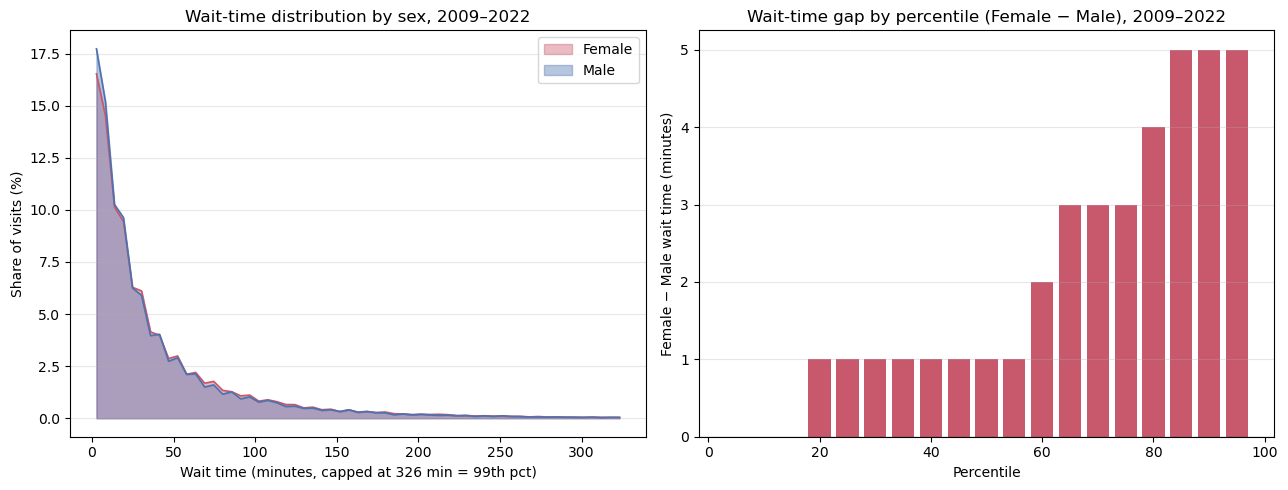

Wait time by percentile (2009–2022):


,Female (min),Male (min),Gap F−M (min)
Percentile,,,
5,1.0,1.0,0.0
10,3.0,3.0,0.0
15,5.0,5.0,0.0
20,7.0,6.0,1.0
25,9.0,8.0,1.0
30,11.0,10.0,1.0
35,14.0,13.0,1.0
40,16.0,15.0,1.0
45,19.0,18.0,1.0


In [59]:
wait_recent = (
    data[(data["YEAR"] >= 2009) & data["WAITTIME"].notna() & data["sex_label"].notna()]
    .copy()
)
# Cap display at 99th percentile to avoid extreme outlier distortion
cap = wait_recent["WAITTIME"].quantile(0.99)
wait_plot = wait_recent[wait_recent["WAITTIME"] <= cap]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- left: overlapping histograms ---
ax = axes[0]
bin_edges = np.linspace(0, cap, 60)
for label, color in [("Female", "#c8586c"), ("Male", "#4c72b0")]:
    vals = wait_plot[wait_plot["sex_label"] == label]["WAITTIME"]
    counts, _ = np.histogram(vals, bins=bin_edges)
    pct = counts / counts.sum() * 100
    midpoints = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax.fill_between(midpoints, pct, alpha=0.4, color=color, label=label)
    ax.plot(midpoints, pct, color=color, linewidth=1.2)
ax.set_xlabel(f"Wait time (minutes, capped at {cap:.0f} min = 99th pct)")
ax.set_ylabel("Share of visits (%)")
ax.set_title("Wait-time distribution by sex, 2009–2022")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# --- right: percentile gap curve ---
ax = axes[1]
pcts = np.arange(5, 96, 5)
f_vals = np.percentile(wait_recent[wait_recent["sex_label"] == "Female"]["WAITTIME"], pcts)
m_vals = np.percentile(wait_recent[wait_recent["sex_label"] == "Male"]["WAITTIME"], pcts)
gap_vals = f_vals - m_vals

ax.bar(pcts, gap_vals, width=4,
       color=["#c8586c" if g > 0 else "#4c72b0" for g in gap_vals])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Percentile")
ax.set_ylabel("Female − Male wait time (minutes)")
ax.set_title("Wait-time gap by percentile (Female − Male), 2009–2022")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Percentile table
pct_table = pd.DataFrame({
    "Percentile": pcts,
    "Female (min)": f_vals.round(1),
    "Male (min)": m_vals.round(1),
    "Gap F−M (min)": gap_vals.round(1),
})
print("Wait time by percentile (2009–2022):")
pct_table.set_index("Percentile")

### 8. Wait time by pain level and triage urgency, compared by sex (2009–2022)

Two lenses:

1. **Pain score (0–10)** — does the wait-time gap widen at higher reported pain?
2. **Pain band × triage acuity** — within each combination of urgency level and pain severity, how large is the female/male wait gap?

All analyses use 2009–2022 (first years both `PAINSCALE` and `IMMEDR` are consistently populated).

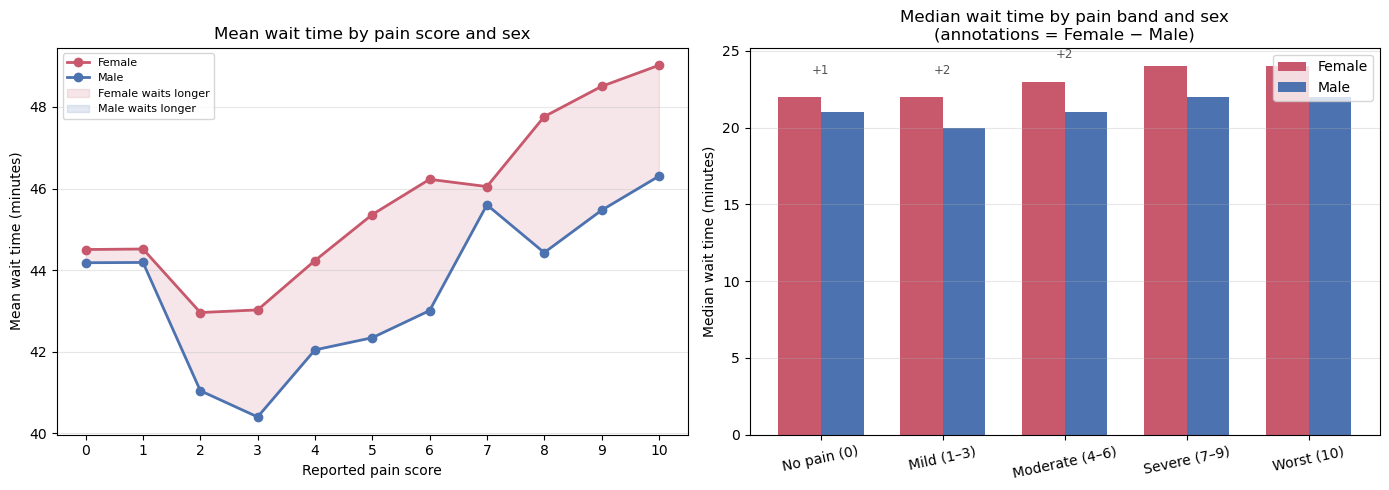

Median wait time by pain band and sex:


sex_label,Female,Male
pain_band,,
No pain (0),22.0,21.0
Mild (1–3),22.0,20.0
Moderate (4–6),23.0,21.0
Severe (7–9),24.0,22.0
Worst (10),24.0,22.0


In [60]:
PAIN_BANDS = {
    "No pain (0)":    (0,  0),
    "Mild (1–3)":     (1,  3),
    "Moderate (4–6)": (4,  6),
    "Severe (7–9)":   (7,  9),
    "Worst (10)":     (10, 10),
}
BAND_ORDER = list(PAIN_BANDS)

def assign_band(score):
    for label, (lo, hi) in PAIN_BANDS.items():
        if lo <= score <= hi:
            return label
    return np.nan

base = (
    data[(data["YEAR"] >= 2009)]
    .dropna(subset=["WAITTIME", "PAINSCALE", "sex_label"])
    .query("WAITTIME >= 0 and PAINSCALE >= 0")
    .copy()
)
base["pain_band"] = base["PAINSCALE"].apply(assign_band)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- left: mean wait time at each integer pain score ---
ax = axes[0]
score_wait = (
    base.groupby(["PAINSCALE", "sex_label"])["WAITTIME"]
    .mean()
    .unstack("sex_label")
)
ax.plot(score_wait.index, score_wait["Female"], color="#c8586c", marker="o",
        label="Female", linewidth=2)
ax.plot(score_wait.index, score_wait["Male"],   color="#4c72b0", marker="o",
        label="Male",   linewidth=2)
ax.fill_between(
    score_wait.index,
    score_wait["Female"], score_wait["Male"],
    where=(score_wait["Female"] > score_wait["Male"]),
    interpolate=True, alpha=0.15, color="#c8586c", label="Female waits longer",
)
ax.fill_between(
    score_wait.index,
    score_wait["Female"], score_wait["Male"],
    where=(score_wait["Female"] <= score_wait["Male"]),
    interpolate=True, alpha=0.15, color="#4c72b0", label="Male waits longer",
)
ax.set_xticks(range(11))
ax.set_xlabel("Reported pain score")
ax.set_ylabel("Mean wait time (minutes)")
ax.set_title("Mean wait time by pain score and sex")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# --- right: median wait time by pain band ---
ax = axes[1]
band_wait = (
    base.dropna(subset=["pain_band"])
    .groupby(["pain_band", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
    .reindex(BAND_ORDER)
)
x = np.arange(len(BAND_ORDER))
w = 0.35
bars_f = ax.bar(x - w/2, band_wait["Female"], w, color="#c8586c", label="Female")
bars_m = ax.bar(x + w/2, band_wait["Male"],   w, color="#4c72b0", label="Male")
for i, (f, m) in enumerate(zip(band_wait["Female"], band_wait["Male"])):
    if not (np.isnan(f) or np.isnan(m)):
        ax.annotate(f"{f - m:+.0f}", (i, max(f, m) + 1.5),
                    ha="center", fontsize=8.5, color="#555")
ax.set_xticks(x)
ax.set_xticklabels(BAND_ORDER, rotation=12)
ax.set_ylabel("Median wait time (minutes)")
ax.set_title("Median wait time by pain band and sex\n(annotations = Female − Male)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("Median wait time by pain band and sex:")
band_wait.round(1)

#### 8b. Female − Male wait gap across every pain-band × triage-acuity combination

The heatmap below shows the median wait-time gap (Female − Male, in minutes) for each cell. Red = women wait longer; blue = men wait longer. Cells with fewer than 30 observations in either sex are masked.

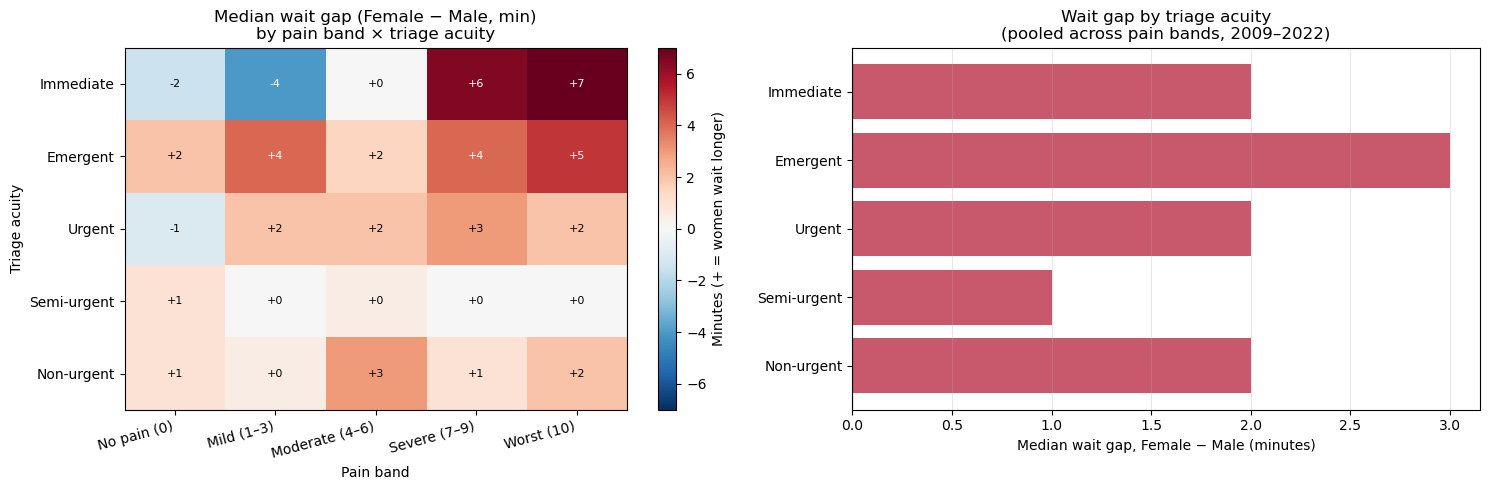

Median wait gap (Female − Male) by triage acuity:


,gap_min
acuity,
Immediate,2.0
Emergent,3.0
Urgent,2.0
Semi-urgent,1.0
Non-urgent,2.0


In [61]:
ACUITY_LABELS = {1: "Immediate", 2: "Emergent", 3: "Urgent", 4: "Semi-urgent", 5: "Non-urgent"}
ACUITY_ORDER  = list(ACUITY_LABELS.values())
MIN_N = 30

cross = (
    base.dropna(subset=["IMMEDR", "pain_band"])
    .assign(acuity=lambda d: d["IMMEDR"].map(ACUITY_LABELS))
    .dropna(subset=["acuity"])
)

# Median wait per (acuity, pain_band, sex)
med = (
    cross.groupby(["acuity", "pain_band", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
)
# Count per cell to mask sparse cells
cnt = (
    cross.groupby(["acuity", "pain_band", "sex_label"])["WAITTIME"]
    .count()
    .unstack("sex_label")
)

gap = med["Female"] - med["Male"]
mask = (cnt["Female"] < MIN_N) | (cnt["Male"] < MIN_N)
gap_masked = gap.where(~mask)

# Reshape to (acuity × pain_band) matrix
heatmap_data = (
    gap_masked
    .reset_index()
    .pivot(index="acuity", columns="pain_band", values=0)
    .reindex(index=ACUITY_ORDER, columns=BAND_ORDER)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- left: heatmap ---
ax = axes[0]
import matplotlib.colors as mcolors
vmax = np.nanmax(np.abs(heatmap_data.values))
cmap = plt.get_cmap("RdBu_r")
im = ax.imshow(heatmap_data.values, cmap=cmap,
               vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(len(BAND_ORDER)))
ax.set_xticklabels(BAND_ORDER, rotation=15, ha="right")
ax.set_yticks(range(len(ACUITY_ORDER)))
ax.set_yticklabels(ACUITY_ORDER)
ax.set_xlabel("Pain band")
ax.set_ylabel("Triage acuity")
ax.set_title("Median wait gap (Female − Male, min)\nby pain band × triage acuity")
plt.colorbar(im, ax=ax, label="Minutes (+ = women wait longer)")
for r, acuity in enumerate(ACUITY_ORDER):
    for c, band in enumerate(BAND_ORDER):
        val = heatmap_data.loc[acuity, band] if acuity in heatmap_data.index and band in heatmap_data.columns else np.nan
        if not np.isnan(val):
            ax.text(c, r, f"{val:+.0f}", ha="center", va="center",
                    fontsize=8, color="white" if abs(val) > vmax * 0.5 else "black")

# --- right: mean gap per acuity level (averaged across pain bands, weighted by N) ---
ax = axes[1]
acuity_gap = (
    cross.groupby(["acuity", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
    .reindex(ACUITY_ORDER)
)
gap_acuity = acuity_gap["Female"] - acuity_gap["Male"]
colors = ["#c8586c" if g > 0 else "#4c72b0" for g in gap_acuity]
ax.barh(ACUITY_ORDER[::-1], gap_acuity.reindex(ACUITY_ORDER[::-1]), color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Median wait gap, Female − Male (minutes)")
ax.set_title("Wait gap by triage acuity\n(pooled across pain bands, 2009–2022)")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print("Median wait gap (Female − Male) by triage acuity:")
gap_acuity.round(1).to_frame("gap_min")

## 9. Treatment rates by sex — ECG, consultations, and anxiolytics (2009–2022)

Expand the loaded column set to include procedure flags (`EKG`, `CONSULT`) and drug category codes (`RX1CAT1`–`RX10CAT1`), then compute per-sex rates for each presenting-complaint group. These values feed directly into the `adam-eve-er.html` presentation.

Complaint filters use primary discharge diagnosis (`DIAG1`): ICD-10 R07.x / ICD-9 7865x (chest pain), R10.x / 7890x (abdominal), R51/G43 / 7840x (headache), M54 / 724x (back), R06 / 7860x (shortness of breath).

`CONSULT == 1` = any specialist consultation ordered — used here as a proxy for cardiology referral in chest/shortness-of-breath presentations.  
Drug category code `059` = benzodiazepines (Multum Lexicon class).

In [62]:
EXTENDED_COLS = [
    "SEX", "WAITTIME", "IMMEDR", "PAINSCALE", "DIAG1",
    "EKG", "CONSULT",
    "RX1CAT1",  "RX2CAT1",  "RX3CAT1",  "RX4CAT1",  "RX5CAT1",
    "RX6CAT1",  "RX7CAT1",  "RX8CAT1",  "RX9CAT1",  "RX10CAT1",
]
TREATMENT_YEARS = list(range(2009, 2023))

frames9 = []
for y in TREATMENT_YEARS:
    try:
        df = pd.read_stata(dta_path(y), convert_categoricals=False)
        df.columns = [c.upper() for c in df.columns]
        keep = [c for c in EXTENDED_COLS if c in df.columns]
        out = df[keep].copy()
        out["YEAR"] = y
        frames9.append(out)
    except Exception as e:
        print(f"  {y}: {e}")

data9 = pd.concat(frames9, ignore_index=True, sort=False)
data9["sex_label"] = data9["SEX"].map({1: "Female", 2: "Male"})
for col in ["WAITTIME", "PAINSCALE", "IMMEDR", "EKG", "CONSULT"]:
    if col in data9.columns:
        data9.loc[data9[col] < 0, col] = np.nan

# Benzodiazepine flag: any of the first 10 RXnCAT1 slots has Multum class 059
rx_cat_cols = [c for c in data9.columns if c.startswith("RX") and c.endswith("CAT1")]
data9["anxiolytic"] = data9[rx_cat_cols].isin(["059", "57", "057"]).any(axis=1).astype(int)

# Complaint filters (ICD-9 5-char string OR ICD-10 prefix)
def make_filter(icd10_prefixes, icd9_prefixes):
    def fn(raw):
        s = str(raw).strip().upper()
        if s[:1].isalpha():
            return any(s.startswith(p) for p in icd10_prefixes)
        return any(s.startswith(p) for p in icd9_prefixes)
    return fn

complaint_filters = {
    "chest":    make_filter(["R07"], ["7865"]),
    "abdominal":make_filter(["R10"], ["7890","7891","7892","7893","7894","7895","7896","7897","7898","7899"]),
    "headache": make_filter(["R51","G43","G44"], ["7840","3460","3461","3462","3463","3464","3465","3466","3467","3468","3469"]),
    "back":     make_filter(["M54"], ["7240","7241","7242","7243","7244","7245","7246","7247","7248","7249"]),
    "shortness":make_filter(["R06"], ["7860","7861","7862","7863","7864","7869"]),
}
for name, fn in complaint_filters.items():
    data9[name] = data9["DIAG1"].apply(fn)

def pain_band9(score):
    if pd.isna(score): return np.nan
    if 1 <= score <= 4:  return "mild"
    if 5 <= score <= 7:  return "moderate"
    if 8 <= score <= 10: return "severe"
    return np.nan
data9["pain_band"] = data9["PAINSCALE"].apply(pain_band9)

complaint_ns = {k: int(data9[k].sum()) for k in complaint_filters}
print(f"Loaded {len(data9):,} visits ({data9['YEAR'].nunique()} years)")
print("Complaint visit counts (by primary diagnosis):", complaint_ns)

Loaded 323,137 visits (14 years)
Complaint visit counts (by primary diagnosis): {'chest': 12270, 'abdominal': 15581, 'headache': 7041, 'back': 8061, 'shortness': 4398}


In [63]:
def compute_rates(df, min_n=50):
    """Return dict of sex → metrics for a filtered sub-DataFrame."""
    g = df.dropna(subset=["sex_label"])
    result = {}
    for sex in ["Male", "Female"]:
        s = g[g["sex_label"] == sex]
        if len(s) < min_n:
            result[sex] = None
            continue
        imm = s["IMMEDR"].dropna()
        ekg = s["EKG"].dropna()
        cons = s["CONSULT"].dropna()
        wt  = s["WAITTIME"].dropna()
        result[sex] = {
            "triage":    round(imm.isin([1, 2]).sum() / len(imm) * 100) if len(imm) else None,
            "ecg":       round((ekg == 1).sum()  / len(ekg)  * 100) if len(ekg)  else None,
            "cardiology":round((cons == 1).sum() / len(cons) * 100) if len(cons) else None,
            "anxiolytic":round(s["anxiolytic"].mean() * 100),
            "wait":      round(wt.median()) if len(wt) else None,
            "n":         len(s),
        }
    return result


explorer_data = {}
for complaint in complaint_filters:
    cdf = data9[data9[complaint]]
    explorer_data[complaint] = {}
    explorer_data[complaint]["all"] = compute_rates(cdf)
    for band in ["mild", "moderate", "severe"]:
        explorer_data[complaint][band] = compute_rates(cdf[cdf["pain_band"] == band])

# Pretty-print
for complaint, bands in explorer_data.items():
    print(f"\n{complaint.upper()}:")
    for band, r in bands.items():
        m, f = r.get("Male"), r.get("Female")
        if m and f:
            print(f"  {band:10} | Male  n={m['n']:5} triage={m['triage']}% wait={m['wait']}min"
                  f" ecg={m['ecg']}% cardio={m['cardiology']}% anx={m['anxiolytic']}%")
            print(f"             | Female n={f['n']:5} triage={f['triage']}% wait={f['wait']}min"
                  f" ecg={f['ecg']}% cardio={f['cardiology']}% anx={f['anxiolytic']}%")
        else:
            print(f"  {band:10} | insufficient data")


CHEST:
  all        | Male  n= 5587 triage=31% wait=17min ecg=83% cardio=16% anx=9%
             | Female n= 6683 triage=29% wait=18min ecg=83% cardio=14% anx=10%
  mild       | Male  n= 1071 triage=35% wait=15min ecg=87% cardio=17% anx=8%
             | Female n=  969 triage=29% wait=18min ecg=85% cardio=15% anx=10%
  moderate   | Male  n= 1381 triage=32% wait=18min ecg=86% cardio=14% anx=8%
             | Female n= 1793 triage=31% wait=18min ecg=85% cardio=14% anx=12%
  severe     | Male  n= 1151 triage=32% wait=18min ecg=80% cardio=16% anx=10%
             | Female n= 1678 triage=31% wait=19min ecg=82% cardio=14% anx=12%

ABDOMINAL:
  all        | Male  n= 5248 triage=8% wait=22min ecg=19% cardio=9% anx=8%
             | Female n=10333 triage=6% wait=24min ecg=15% cardio=8% anx=9%
  mild       | Male  n=  645 triage=6% wait=21min ecg=19% cardio=7% anx=8%
             | Female n=  926 triage=5% wait=24min ecg=15% cardio=8% anx=11%
  moderate   | Male  n= 1281 triage=6% wait=23min ec

In [64]:
import json

def to_js_entry(m, f, fallback_m, fallback_f):
    """Build the [male_val, female_val] pairs for the JS explorerData object."""
    if m is None or f is None:
        return {"triage": fallback_m["triage"], "wait": fallback_m["wait"],
                "ecg": fallback_m["ecg"], "cardiology": fallback_m["cardiology"],
                "anxiolytic": fallback_m["anxiolytic"]}
    return {
        "triage":    [m["triage"],    f["triage"]],
        "wait":      [m["wait"],      f["wait"]],
        "ecg":       [m["ecg"],       f["ecg"]],
        "cardiology":[m["cardiology"],f["cardiology"]],
        "anxiolytic":[m["anxiolytic"],f["anxiolytic"]],
    }

print("// ── explorerData — paste into adam-eve-er.html ──")
print("const explorerData = {")
for complaint, bands in explorer_data.items():
    fallback_m = bands["all"]["Male"]
    fallback_f = bands["all"]["Female"]
    print(f"  {complaint}: {{")
    for band in ["severe","moderate","mild","all"]:
        r  = bands.get(band, {})
        m  = r.get("Male")
        f  = r.get("Female")
        entry = to_js_entry(m, f, fallback_m, fallback_f)
        triage = entry["triage"] if isinstance(entry["triage"], list) else [entry["triage"]["Male"], entry["triage"]["Female"]]
        wait   = entry["wait"]   if isinstance(entry["wait"],   list) else [entry["wait"]["Male"],   entry["wait"]["Female"]]
        ecg    = entry["ecg"]    if isinstance(entry["ecg"],    list) else [entry["ecg"]["Male"],    entry["ecg"]["Female"]]
        card   = entry["cardiology"] if isinstance(entry["cardiology"], list) else [0,0]
        anx    = entry["anxiolytic"] if isinstance(entry["anxiolytic"], list) else [0,0]
        comma  = "," if band != "all" else ""
        print(f"    {band}:     {{ triage: {triage}, wait: {wait}, ecg: {ecg}, cardiology: {card}, anxiolytic: {anx} }}{comma}")
    print("  },")
print("};")

# Narrative stat summary
print("\n// ── Narrative stats (chest pain, all pain levels) ──")
cm = explorer_data["chest"]["all"].get("Male")
cf = explorer_data["chest"]["all"].get("Female")
if cm and cf:
    print(f"// Adam (Male) chest pain: wait={cm['wait']} min, triage ESI1-2={cm['triage']}%,"
          f" ecg={cm['ecg']}%, cardiology={cm['cardiology']}%, anxiolytic={cm['anxiolytic']}%")
    print(f"// Eve (Female) chest pain: wait={cf['wait']} min, triage ESI1-2={cf['triage']}%,"
          f" ecg={cf['ecg']}%, cardiology={cf['cardiology']}%, anxiolytic={cf['anxiolytic']}%")

// ── explorerData — paste into adam-eve-er.html ──
const explorerData = {
  chest: {
    severe:     { triage: [32, 31], wait: [18, 19], ecg: [80, 82], cardiology: [16, 14], anxiolytic: [10, 12] },
    moderate:     { triage: [32, 31], wait: [18, 18], ecg: [86, 85], cardiology: [14, 14], anxiolytic: [8, 12] },
    mild:     { triage: [35, 29], wait: [15, 18], ecg: [87, 85], cardiology: [17, 15], anxiolytic: [8, 10] },
    all:     { triage: [31, 29], wait: [17, 18], ecg: [83, 83], cardiology: [16, 14], anxiolytic: [9, 10] }
  },
  abdominal: {
    severe:     { triage: [10, 6], wait: [22, 24], ecg: [20, 14], cardiology: [10, 8], anxiolytic: [7, 9] },
    moderate:     { triage: [6, 5], wait: [23, 25], ecg: [20, 13], cardiology: [8, 7], anxiolytic: [8, 10] },
    mild:     { triage: [6, 5], wait: [21, 24], ecg: [19, 15], cardiology: [7, 8], anxiolytic: [8, 11] },
    all:     { triage: [8, 6], wait: [22, 24], ecg: [19, 15], cardiology: [9, 8], anxiolytic: [8, 9] }
  },
  headache: {
  

## 10. Wait time by race/ethnicity and sex (2009–2022)

`RACERETH` is a consistent four-category combined race/ethnicity variable available from 2009 onward:

| Code | Group |
|------|-------|
| 1 | Non-Hispanic White |
| 2 | Non-Hispanic Black |
| 3 | Hispanic |
| 4 | Non-Hispanic Other (Asian, AIAN, multiracial) |

Three questions:
- **10a** How does median wait time differ by race and sex?
- **10b** Does the female–male wait gap vary by race?
- **10c** How do wait times by race × sex interact with triage acuity and pain score?

In [65]:
RACE_YEARS = list(range(2009, 2023))
RACE_COLS  = ["SEX", "RACERETH", "WAITTIME", "IMMEDR", "PAINSCALE"]

race_frames = []
for y in RACE_YEARS:
    try:
        df = pd.read_stata(dta_path(y), convert_categoricals=False)
        df.columns = [c.upper() for c in df.columns]
        keep = [c for c in RACE_COLS if c in df.columns]
        out = df[keep].copy()
        out["YEAR"] = y
        race_frames.append(out)
    except Exception as e:
        print(f"  {y}: {e}")

race_data = pd.concat(race_frames, ignore_index=True, sort=False)

RACE_LABELS = {1: "NH White", 2: "NH Black", 3: "Hispanic", 4: "NH Other"}
RACE_ORDER  = list(RACE_LABELS.values())
RACE_COLORS = {"NH White": "#4878d0", "NH Black": "#ee854a",
               "Hispanic": "#6acc65", "NH Other": "#956cb4"}

race_data["sex_label"]  = race_data["SEX"].map({1: "Female", 2: "Male"})
race_data["race_label"] = race_data["RACERETH"].map(RACE_LABELS)
for col in ["WAITTIME", "PAINSCALE", "IMMEDR"]:
    race_data.loc[race_data[col] < 0, col] = np.nan

# Sample sizes
counts = (
    race_data.dropna(subset=["race_label", "sex_label", "WAITTIME"])
    .groupby(["race_label", "sex_label"])
    .size()
    .unstack("sex_label")
    .reindex(RACE_ORDER)
)
print("Sample sizes (visits with valid WAITTIME, 2009–2022):")
counts

Sample sizes (visits with valid WAITTIME, 2009–2022):


sex_label,Female,Male
race_label,,
NH White,86889,72343
NH Black,35275,28654
Hispanic,23242,20250
NH Other,5724,4974


### 10a. Median wait time and female–male gap by race

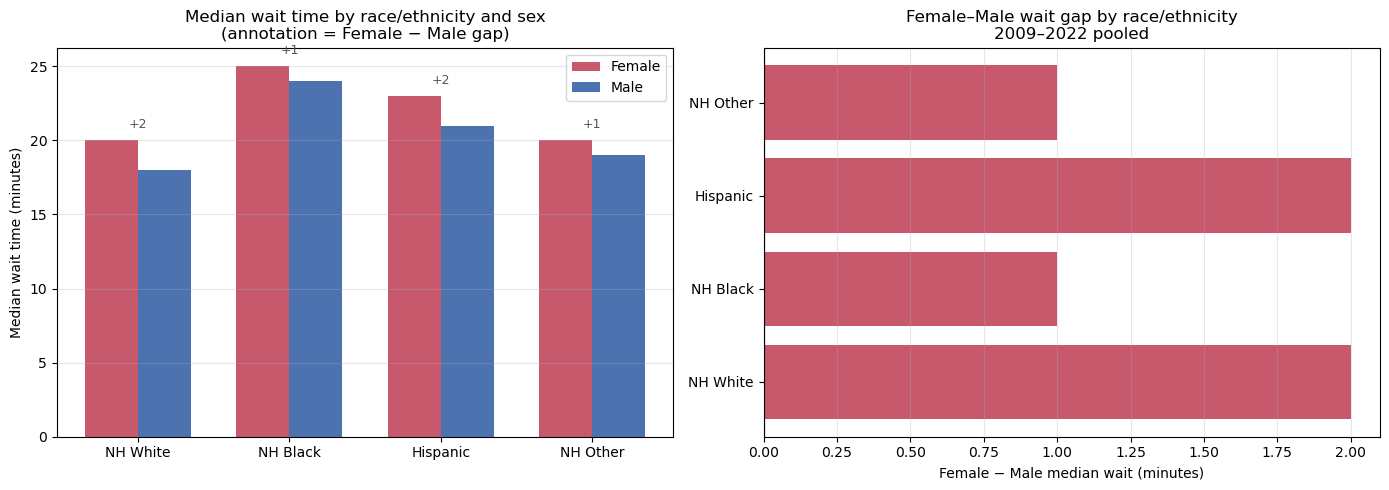

Median wait time and F−M gap by race (2009–2022):


sex_label,Female,Male,F−M gap
race_label,,,
NH White,20.0,18.0,2.0
NH Black,25.0,24.0,1.0
Hispanic,23.0,21.0,2.0
NH Other,20.0,19.0,1.0


In [66]:
base_race = race_data.dropna(subset=["race_label", "sex_label", "WAITTIME"]).copy()

med_by_race_sex = (
    base_race.groupby(["race_label", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
    .reindex(RACE_ORDER)
)
gap_by_race = (med_by_race_sex["Female"] - med_by_race_sex["Male"]).rename("gap_min")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- left: grouped bars, median wait by race × sex ---
ax = axes[0]
x = np.arange(len(RACE_ORDER))
w = 0.35
f_vals = med_by_race_sex["Female"].to_numpy()
m_vals = med_by_race_sex["Male"].to_numpy()
ax.bar(x - w/2, f_vals, w, color="#c8586c", label="Female")
ax.bar(x + w/2, m_vals, w, color="#4c72b0", label="Male")
for i, (f, m) in enumerate(zip(f_vals, m_vals)):
    ax.annotate(f"{f - m:+.0f}", (i, max(f, m) + 0.8),
                ha="center", fontsize=9, color="#555")
ax.set_xticks(x)
ax.set_xticklabels(RACE_ORDER)
ax.set_ylabel("Median wait time (minutes)")
ax.set_title("Median wait time by race/ethnicity and sex\n(annotation = Female − Male gap)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# --- right: F−M gap by race, horizontal bar ---
ax = axes[1]
gap_vals = gap_by_race.reindex(RACE_ORDER).to_numpy()
colors   = ["#c8586c" if g > 0 else "#4c72b0" for g in gap_vals]
ax.barh(RACE_ORDER, gap_vals, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Female − Male median wait (minutes)")
ax.set_title("Female–Male wait gap by race/ethnicity\n2009–2022 pooled")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print("Median wait time and F−M gap by race (2009–2022):")
med_by_race_sex.round(1).assign(**{"F−M gap": gap_by_race.round(1)})

### 10b. Wait gap trend over time by race

Do the racial and gender gaps widen or narrow across the 2009–2022 period?

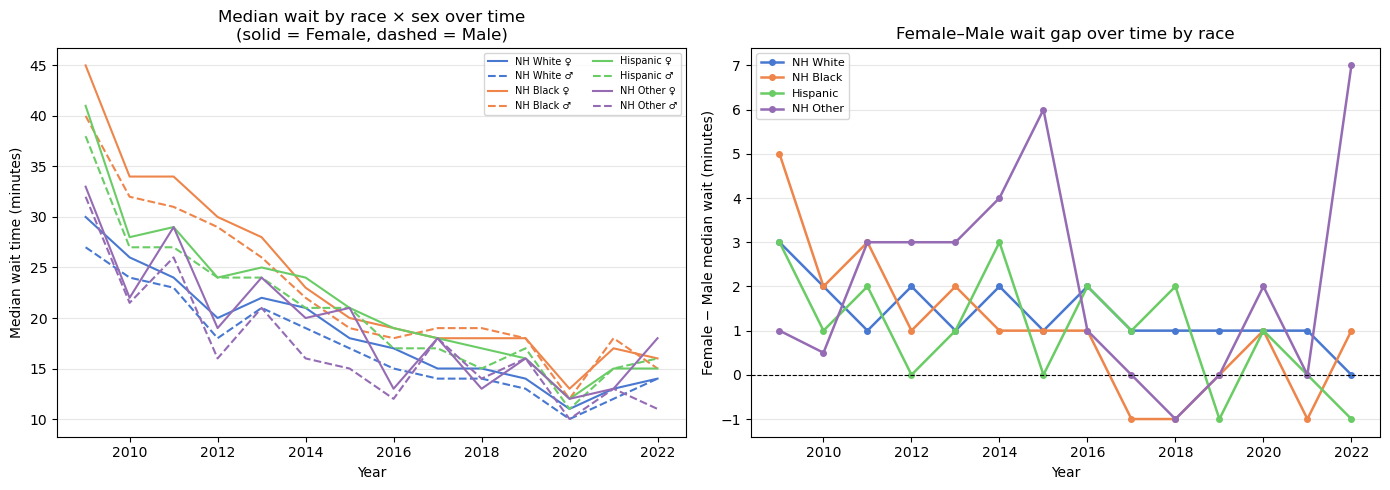

In [67]:
yearly = (
    base_race.groupby(["YEAR", "race_label", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
)
yearly_gap = (yearly["Female"] - yearly["Male"]).reset_index()
yearly_gap.columns = ["YEAR", "race_label", "gap_min"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- left: median wait over time, one line per race × sex (8 lines) ---
ax = axes[0]
line_styles = {"Female": "-", "Male": "--"}
for race in RACE_ORDER:
    color = RACE_COLORS[race]
    for sex, ls in line_styles.items():
        sub = (
            base_race[(base_race["race_label"] == race) & (base_race["sex_label"] == sex)]
            .groupby("YEAR")["WAITTIME"].median()
        )
        ax.plot(sub.index, sub.values, color=color, linestyle=ls, linewidth=1.5,
                label=f"{race} {'♀' if sex == 'Female' else '♂'}")
ax.set_xlabel("Year")
ax.set_ylabel("Median wait time (minutes)")
ax.set_title("Median wait by race × sex over time\n(solid = Female, dashed = Male)")
ax.legend(fontsize=7, ncol=2)
ax.grid(axis="y", alpha=0.3)

# --- right: F−M gap over time by race ---
ax = axes[1]
for race in RACE_ORDER:
    sub = yearly_gap[yearly_gap["race_label"] == race].set_index("YEAR")["gap_min"]
    ax.plot(sub.index, sub.values, color=RACE_COLORS[race], marker="o",
            linewidth=1.8, markersize=4, label=race)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Year")
ax.set_ylabel("Female − Male median wait (minutes)")
ax.set_title("Female–Male wait gap over time by race")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 10c. Wait gap by triage acuity × race × sex, and pain score by race × sex

Left heatmap: median wait gap (Female − Male) for each race × triage-acuity cell. Cells with fewer than 30 observations in either sex are masked.  
Right: median reported pain score by race and sex — helps interpret whether pain reporting differences drive any wait-time patterns.

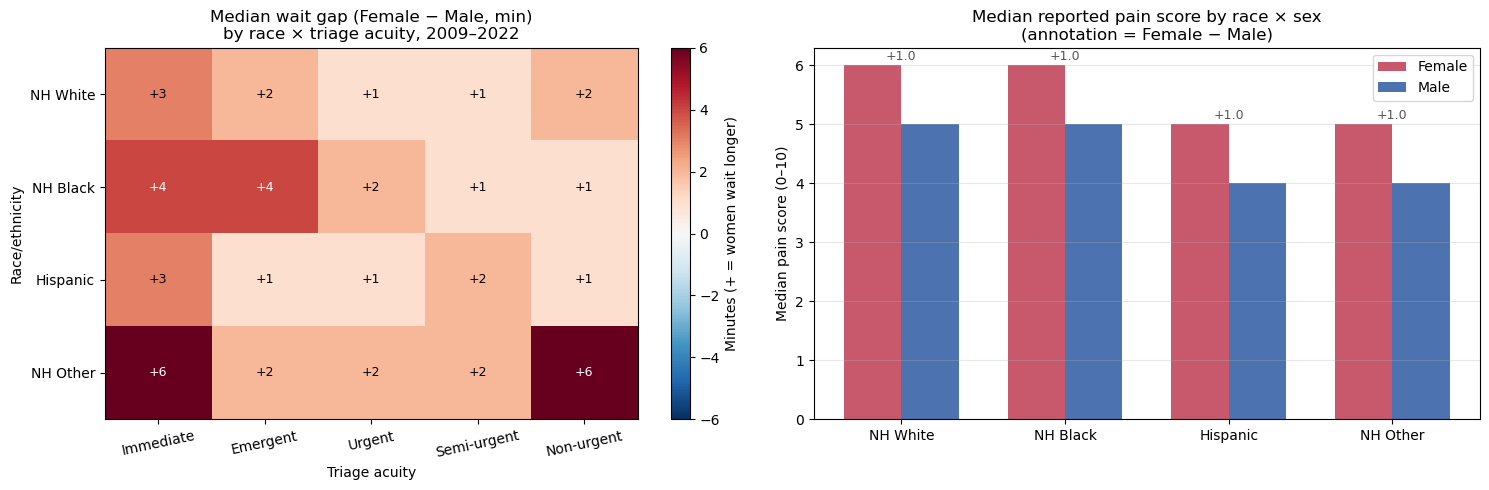

Median pain score by race and sex:


sex_label,Female,Male,F−M
race_label,,,
NH White,6.0,5.0,1.0
NH Black,6.0,5.0,1.0
Hispanic,5.0,4.0,1.0
NH Other,5.0,4.0,1.0


In [68]:
acuity_race = (
    base_race.dropna(subset=["IMMEDR"])
    .assign(acuity=lambda d: d["IMMEDR"].map(ACUITY_LABELS))
    .dropna(subset=["acuity", "race_label"])
)

# Median wait per (race, acuity, sex)
med_ras = (
    acuity_race.groupby(["race_label", "acuity", "sex_label"])["WAITTIME"]
    .median().unstack("sex_label")
)
cnt_ras = (
    acuity_race.groupby(["race_label", "acuity", "sex_label"])["WAITTIME"]
    .count().unstack("sex_label")
)
gap_ras = (med_ras["Female"] - med_ras["Male"]).where(
    (cnt_ras["Female"] >= 30) & (cnt_ras["Male"] >= 30)
)

hm = (
    gap_ras.reset_index()
    .pivot(index="race_label", columns="acuity", values=0)
    .reindex(index=RACE_ORDER, columns=ACUITY_ORDER)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- left: heatmap race × acuity ---
ax = axes[0]
vmax = np.nanmax(np.abs(hm.values))
cmap = plt.get_cmap("RdBu_r")
im = ax.imshow(hm.values, cmap=cmap, vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(len(ACUITY_ORDER)))
ax.set_xticklabels(ACUITY_ORDER, rotation=12)
ax.set_yticks(range(len(RACE_ORDER)))
ax.set_yticklabels(RACE_ORDER)
ax.set_xlabel("Triage acuity")
ax.set_ylabel("Race/ethnicity")
ax.set_title("Median wait gap (Female − Male, min)\nby race × triage acuity, 2009–2022")
plt.colorbar(im, ax=ax, label="Minutes (+ = women wait longer)")
for r, race in enumerate(RACE_ORDER):
    for c, acuity in enumerate(ACUITY_ORDER):
        val = hm.loc[race, acuity] if race in hm.index and acuity in hm.columns else np.nan
        if not np.isnan(val):
            ax.text(c, r, f"{val:+.0f}", ha="center", va="center",
                    fontsize=9, color="white" if abs(val) > vmax * 0.55 else "black")

# --- right: median pain score by race × sex ---
ax = axes[1]
pain_race = (
    race_data.dropna(subset=["race_label", "sex_label", "PAINSCALE"])
    .query("PAINSCALE >= 0")
    .groupby(["race_label", "sex_label"])["PAINSCALE"]
    .median()
    .unstack("sex_label")
    .reindex(RACE_ORDER)
)
x = np.arange(len(RACE_ORDER))
w = 0.35
ax.bar(x - w/2, pain_race["Female"], w, color="#c8586c", label="Female")
ax.bar(x + w/2, pain_race["Male"],   w, color="#4c72b0", label="Male")
for i, (f, m) in enumerate(zip(pain_race["Female"], pain_race["Male"])):
    if not (np.isnan(f) or np.isnan(m)):
        ax.annotate(f"{f - m:+.1f}", (i, max(f, m) + 0.1),
                    ha="center", fontsize=9, color="#555")
ax.set_xticks(x)
ax.set_xticklabels(RACE_ORDER)
ax.set_ylabel("Median pain score (0–10)")
ax.set_title("Median reported pain score by race × sex\n(annotation = Female − Male)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("Median pain score by race and sex:")
pain_race.round(2).assign(**{"F−M": (pain_race["Female"] - pain_race["Male"]).round(2)})

## 11. Hospital characteristics — does the sex gap vary by setting?

Three hospital-level cuts of the sex wait-time disparity:

| Dimension | Variable | Coding | Years available |
|---|---|---|---|
| **Teaching vs. Non-teaching** | `EMEDRES` | 1 = EM residency program (teaching), 2 = No | 2014–2022 |
| **Urban vs. Rural** | `MSA` | 1 = Metro (urban), 2 = Non-metro (rural) | 2009–2022 (ex 2012) |
| **High vs. Low volume** | `HOSPCODE` sampled visits | above/below yearly median | 2009–2022 |

All analyses use only years where the relevant column is present and restrict to visits with valid `WAITTIME` and `SEX`.

In [ ]:
HOSP_COLS = ["SEX", "WAITTIME", "IMMEDR", "PAINSCALE", "EMEDRES", "MSA", "HOSPCODE"]
HOSP_YEARS = list(range(2009, 2023))

hosp_frames = []
for y in HOSP_YEARS:
    try:
        df = pd.read_stata(dta_path(y), convert_categoricals=False)
        df.columns = [c.upper() for c in df.columns]
        keep = [c for c in HOSP_COLS if c in df.columns]
        out = df[keep].copy()
        out["YEAR"] = y
        hosp_frames.append(out)
    except Exception as e:
        print(f"  {y}: {e}")

hosp = pd.concat(hosp_frames, ignore_index=True, sort=False)
hosp["sex_label"] = hosp["SEX"].map({1: "Female", 2: "Male"})
for col in ["WAITTIME", "PAINSCALE", "IMMEDR"]:
    hosp.loc[hosp[col] < 0, col] = np.nan

# Urban/rural label
hosp["msa_label"] = hosp["MSA"].map({1: "Urban (Metro)", 2: "Rural (Non-metro)"})

# Teaching label (2014+ only; -8 = not ascertained → drop)
hosp["teach_label"] = hosp["EMEDRES"].map({1: "Teaching", 2: "Non-teaching"}) if "EMEDRES" in hosp.columns else np.nan

# High/low volume: count sampled visits per HOSPCODE per year, then split at yearly median
visit_counts = (
    hosp.groupby(["YEAR", "HOSPCODE"])
    .size()
    .reset_index(name="hosp_year_n")
)
yearly_median = visit_counts.groupby("YEAR")["hosp_year_n"].median().rename("median_n")
visit_counts = visit_counts.join(yearly_median, on="YEAR")
visit_counts["vol_label"] = np.where(
    visit_counts["hosp_year_n"] >= visit_counts["median_n"], "High volume", "Low volume"
)
hosp = hosp.merge(visit_counts[["YEAR", "HOSPCODE", "vol_label"]], on=["YEAR", "HOSPCODE"], how="left")

base_hosp = hosp.dropna(subset=["sex_label", "WAITTIME"]).copy()

print(f"Loaded {len(base_hosp):,} visits with valid WAITTIME ({base_hosp['YEAR'].nunique()} years)")
print("Teaching label counts:", base_hosp["teach_label"].value_counts().to_dict())
print("MSA label counts:", base_hosp["msa_label"].value_counts().to_dict())
print("Volume label counts:", base_hosp["vol_label"].value_counts().to_dict())

### 11a. Teaching vs. Non-teaching hospitals (2014–2022)

`EMEDRES = 1` indicates the hospital has an emergency medicine residency program — the standard NHAMCS proxy for teaching status. Does the sex gap persist in academic medical centres, where evidence-based protocols are more likely to be standardised?

In [ ]:
teach = base_hosp.dropna(subset=["teach_label"]).copy()
TEACH_ORDER = ["Teaching", "Non-teaching"]
TEACH_COLORS = {"Teaching": "#2d6a4f", "Non-teaching": "#d62828"}

# Median wait time by teaching × sex
med_teach = (
    teach.groupby(["teach_label", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
    .reindex(TEACH_ORDER)
)
gap_teach = (med_teach["Female"] - med_teach["Male"]).rename("gap_min")

# Triage acuity (ESI 1-2 rate) by teaching × sex
acuity_teach = (
    teach.dropna(subset=["IMMEDR"])
    .groupby(["teach_label", "sex_label"])["IMMEDR"]
    .apply(lambda x: (x.isin([1, 2])).mean() * 100)
    .unstack("sex_label")
    .reindex(TEACH_ORDER)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- left: wait time bars ---
ax = axes[0]
x = np.arange(len(TEACH_ORDER))
w = 0.35
ax.bar(x - w/2, med_teach["Female"], w, color="#c8586c", label="Female")
ax.bar(x + w/2, med_teach["Male"],   w, color="#4c72b0", label="Male")
for i, (f, m) in enumerate(zip(med_teach["Female"], med_teach["Male"])):
    ax.annotate(f"{f - m:+.0f}", (i, max(f, m) + 0.8), ha="center", fontsize=10, color="#555")
ax.set_xticks(x); ax.set_xticklabels(TEACH_ORDER)
ax.set_ylabel("Median wait time (minutes)")
ax.set_title("Median wait time by teaching status\n(annotation = F − M gap)")
ax.legend(); ax.grid(axis="y", alpha=0.3)

# --- middle: F-M gap bar ---
ax = axes[1]
colors = ["#c8586c" if g > 0 else "#4c72b0" for g in gap_teach]
ax.bar(TEACH_ORDER, gap_teach, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Female − Male median wait (minutes)")
ax.set_title("Wait gap by teaching status\n2014–2022 pooled")
ax.grid(axis="y", alpha=0.3)

# --- right: triage acuity (ESI 1-2 %) ---
ax = axes[2]
ax.bar(x - w/2, acuity_teach["Female"], w, color="#c8586c", label="Female")
ax.bar(x + w/2, acuity_teach["Male"],   w, color="#4c72b0", label="Male")
for i, (f, m) in enumerate(zip(acuity_teach["Female"], acuity_teach["Male"])):
    ax.annotate(f"{f - m:+.1f}pp", (i, max(f, m) + 0.3), ha="center", fontsize=9, color="#555")
ax.set_xticks(x); ax.set_xticklabels(TEACH_ORDER)
ax.set_ylabel("Visits triaged ESI 1–2 (%)")
ax.set_title("High-acuity triage rate by sex\nand teaching status")
ax.legend(); ax.grid(axis="y", alpha=0.3)

plt.suptitle("Teaching vs. Non-teaching hospitals — sex disparities (2014–2022)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Summary — median wait and triage acuity by teaching status and sex:")
summary_teach = med_teach.round(1).copy()
summary_teach.columns = ["Female wait (min)", "Male wait (min)"]
summary_teach["F−M gap (min)"] = gap_teach.round(1)
summary_teach["Female ESI1-2 (%)"] = acuity_teach["Female"].round(1)
summary_teach["Male ESI1-2 (%)"]   = acuity_teach["Male"].round(1)
summary_teach["F−M triage gap (pp)"] = (acuity_teach["Female"] - acuity_teach["Male"]).round(1)
summary_teach

### 11b. Urban vs. Rural hospitals (2009–2022, excl. 2012)

`MSA = 1` (Metropolitan Statistical Area) = urban; `MSA = 2` = rural. Rural EDs tend to be smaller, less staffed, and may serve a different patient mix. Does the sex disparity shrink or widen in rural settings?

In [ ]:
msa = base_hosp.dropna(subset=["msa_label"]).copy()
MSA_ORDER = ["Urban (Metro)", "Rural (Non-metro)"]

med_msa = (
    msa.groupby(["msa_label", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
    .reindex(MSA_ORDER)
)
gap_msa = (med_msa["Female"] - med_msa["Male"]).rename("gap_min")

# Year-by-year gap trend by MSA status
yearly_msa = (
    msa.groupby(["YEAR", "msa_label", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
)
yearly_msa_gap = (yearly_msa["Female"] - yearly_msa["Male"]).reset_index()
yearly_msa_gap.columns = ["YEAR", "msa_label", "gap_min"]

# Triage by MSA × sex
acuity_msa = (
    msa.dropna(subset=["IMMEDR"])
    .groupby(["msa_label", "sex_label"])["IMMEDR"]
    .apply(lambda x: (x.isin([1, 2])).mean() * 100)
    .unstack("sex_label")
    .reindex(MSA_ORDER)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- left: median wait grouped bars ---
ax = axes[0]
x = np.arange(len(MSA_ORDER))
w = 0.35
ax.bar(x - w/2, med_msa["Female"], w, color="#c8586c", label="Female")
ax.bar(x + w/2, med_msa["Male"],   w, color="#4c72b0", label="Male")
for i, (f, m) in enumerate(zip(med_msa["Female"], med_msa["Male"])):
    ax.annotate(f"{f - m:+.0f}", (i, max(f, m) + 0.8), ha="center", fontsize=10, color="#555")
ax.set_xticks(x); ax.set_xticklabels(MSA_ORDER)
ax.set_ylabel("Median wait time (minutes)")
ax.set_title("Median wait time by urban/rural and sex\n(annotation = F − M gap)")
ax.legend(); ax.grid(axis="y", alpha=0.3)

# --- middle: gap trend over time ---
ax = axes[1]
MSA_CMAP = {"Urban (Metro)": "#e07b54", "Rural (Non-metro)": "#3a7ebf"}
for label in MSA_ORDER:
    sub = yearly_msa_gap[yearly_msa_gap["msa_label"] == label].set_index("YEAR")["gap_min"]
    ax.plot(sub.index, sub.values, color=MSA_CMAP[label], marker="o",
            linewidth=1.8, markersize=4, label=label)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Year")
ax.set_ylabel("Female − Male median wait (minutes)")
ax.set_title("F−M wait gap trend by urban/rural\n2009–2022")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

# --- right: triage acuity ---
ax = axes[2]
ax.bar(x - w/2, acuity_msa["Female"], w, color="#c8586c", label="Female")
ax.bar(x + w/2, acuity_msa["Male"],   w, color="#4c72b0", label="Male")
for i, (f, m) in enumerate(zip(acuity_msa["Female"], acuity_msa["Male"])):
    ax.annotate(f"{f - m:+.1f}pp", (i, max(f, m) + 0.3), ha="center", fontsize=9, color="#555")
ax.set_xticks(x); ax.set_xticklabels(MSA_ORDER)
ax.set_ylabel("Visits triaged ESI 1–2 (%)")
ax.set_title("High-acuity triage rate by sex\nand urban/rural status")
ax.legend(); ax.grid(axis="y", alpha=0.3)

plt.suptitle("Urban vs. Rural hospitals — sex disparities (2009–2022)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Median wait, F−M gap, and triage rates by MSA status:")
summary_msa = med_msa.round(1).copy()
summary_msa.columns = ["Female wait (min)", "Male wait (min)"]
summary_msa["F−M gap (min)"] = gap_msa.round(1)
summary_msa["Female ESI1-2 (%)"] = acuity_msa["Female"].round(1)
summary_msa["Male ESI1-2 (%)"]   = acuity_msa["Male"].round(1)
summary_msa["F−M triage gap (pp)"] = (acuity_msa["Female"] - acuity_msa["Male"]).round(1)
summary_msa

### 11c. High vs. Low volume hospitals (2009–2022)

NHAMCS does not publish hospital annual visit volume directly in the patient-level file. As a proxy, we count sampled visits per `HOSPCODE` per year and split at the yearly median: hospitals at or above the median are "High volume", those below are "Low volume". Busier EDs are under more throughput pressure, which could widen the sex gap if women's presentations are less visually urgent.

In [ ]:
vol = base_hosp.dropna(subset=["vol_label"]).copy()
VOL_ORDER = ["High volume", "Low volume"]

med_vol = (
    vol.groupby(["vol_label", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
    .reindex(VOL_ORDER)
)
gap_vol = (med_vol["Female"] - med_vol["Male"]).rename("gap_min")

# Year-by-year gap by volume tier
yearly_vol = (
    vol.groupby(["YEAR", "vol_label", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
)
yearly_vol_gap = (yearly_vol["Female"] - yearly_vol["Male"]).reset_index()
yearly_vol_gap.columns = ["YEAR", "vol_label", "gap_min"]

# Triage by volume × sex
acuity_vol = (
    vol.dropna(subset=["IMMEDR"])
    .groupby(["vol_label", "sex_label"])["IMMEDR"]
    .apply(lambda x: (x.isin([1, 2])).mean() * 100)
    .unstack("sex_label")
    .reindex(VOL_ORDER)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- left: median wait grouped bars ---
ax = axes[0]
x = np.arange(len(VOL_ORDER))
w = 0.35
ax.bar(x - w/2, med_vol["Female"], w, color="#c8586c", label="Female")
ax.bar(x + w/2, med_vol["Male"],   w, color="#4c72b0", label="Male")
for i, (f, m) in enumerate(zip(med_vol["Female"], med_vol["Male"])):
    ax.annotate(f"{f - m:+.0f}", (i, max(f, m) + 0.8), ha="center", fontsize=10, color="#555")
ax.set_xticks(x); ax.set_xticklabels(VOL_ORDER)
ax.set_ylabel("Median wait time (minutes)")
ax.set_title("Median wait time by volume tier and sex\n(annotation = F − M gap)")
ax.legend(); ax.grid(axis="y", alpha=0.3)

# --- middle: gap trend over time ---
ax = axes[1]
VOL_CMAP = {"High volume": "#9b2226", "Low volume": "#457b9d"}
for label in VOL_ORDER:
    sub = yearly_vol_gap[yearly_vol_gap["vol_label"] == label].set_index("YEAR")["gap_min"]
    ax.plot(sub.index, sub.values, color=VOL_CMAP[label], marker="o",
            linewidth=1.8, markersize=4, label=label)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Year")
ax.set_ylabel("Female − Male median wait (minutes)")
ax.set_title("F−M wait gap trend by volume tier\n2009–2022")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

# --- right: triage acuity ---
ax = axes[2]
ax.bar(x - w/2, acuity_vol["Female"], w, color="#c8586c", label="Female")
ax.bar(x + w/2, acuity_vol["Male"],   w, color="#4c72b0", label="Male")
for i, (f, m) in enumerate(zip(acuity_vol["Female"], acuity_vol["Male"])):
    ax.annotate(f"{f - m:+.1f}pp", (i, max(f, m) + 0.3), ha="center", fontsize=9, color="#555")
ax.set_xticks(x); ax.set_xticklabels(VOL_ORDER)
ax.set_ylabel("Visits triaged ESI 1–2 (%)")
ax.set_title("High-acuity triage rate by sex\nand volume tier")
ax.legend(); ax.grid(axis="y", alpha=0.3)

plt.suptitle("High vs. Low volume hospitals — sex disparities (2009–2022)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Median wait, F−M gap, and triage rates by volume tier:")
summary_vol = med_vol.round(1).copy()
summary_vol.columns = ["Female wait (min)", "Male wait (min)"]
summary_vol["F−M gap (min)"] = gap_vol.round(1)
summary_vol["Female ESI1-2 (%)"] = acuity_vol["Female"].round(1)
summary_vol["Male ESI1-2 (%)"]   = acuity_vol["Male"].round(1)
summary_vol["F−M triage gap (pp)"] = (acuity_vol["Female"] - acuity_vol["Male"]).round(1)
summary_vol

## 12. Wait time within pain bands — all dimensions compared (2014–2022)

The analyses in sections 10 and 11 each look at one dimension in isolation. Here we hold **pain level constant** and ask how much each factor shifts the wait time, so comparisons are made only among patients who reported the same severity.

Dimensions compared simultaneously:
- **Sex** — Female vs. Male  
- **Race/ethnicity** — NH White, NH Black, Hispanic, NH Other  
- **Teaching status** — Teaching (EMEDRES=1) vs. Non-teaching  
- **Urban/rural** — Urban (MSA=1) vs. Rural  
- **Hospital volume** — High vs. Low (sampled visits per HOSPCODE, yearly median split)

All five dimensions are drawn from the same 2014–2022 pooled dataset so cell sizes are consistent.

In [98]:
COMBINED_COLS = ["SEX", "WAITTIME", "PAINSCALE", "RACERETH", "EMEDRES", "MSA", "HOSPCODE"]
COMBINED_YEARS = list(range(2014, 2023))

comb_frames = []
for y in COMBINED_YEARS:
    try:
        df = pd.read_stata(dta_path(y), convert_categoricals=False)
        df.columns = [c.upper() for c in df.columns]
        out = df[COMBINED_COLS].copy()
        out["YEAR"] = y
        comb_frames.append(out)
    except Exception as e:
        print(f"  {y}: {e}")

comb = pd.concat(comb_frames, ignore_index=True, sort=False)

# Clean sentinels
for col in ["WAITTIME", "PAINSCALE"]:
    comb.loc[comb[col] < 0, col] = np.nan

# Labels
comb["sex_label"]   = comb["SEX"].map({1: "Female", 2: "Male"})
comb["race_label"]  = comb["RACERETH"].map({1: "NH White", 2: "NH Black", 3: "Hispanic", 4: "NH Other"})
comb["teach_label"] = comb["EMEDRES"].map({1: "Teaching", 2: "Non-teaching"})
comb["msa_label"]   = comb["MSA"].map({1: "Urban", 2: "Rural"})

# Volume: yearly median split on sampled visits per HOSPCODE
vc = (
    comb.groupby(["YEAR", "HOSPCODE"]).size()
    .reset_index(name="n")
)
vc = vc.join(vc.groupby("YEAR")["n"].median().rename("med_n"), on="YEAR")
vc["vol_label"] = np.where(vc["n"] >= vc["med_n"], "High vol", "Low vol")
comb = comb.merge(vc[["YEAR", "HOSPCODE", "vol_label"]], on=["YEAR", "HOSPCODE"], how="left")

# Pain bands (same boundaries as section 8)
PAIN_BANDS_12 = [
    ("No pain (0)",    0,  0),
    ("Mild (1–3)",     1,  3),
    ("Moderate (4–6)", 4,  6),
    ("Severe (7–9)",   7,  9),
    ("Worst (10)",    10, 10),
]
BAND_NAMES_12 = [b[0] for b in PAIN_BANDS_12]

def band_fn(score):
    for name, lo, hi in PAIN_BANDS_12:
        if lo <= score <= hi:
            return name
    return np.nan

comb["pain_band"] = comb["PAINSCALE"].apply(band_fn)

# Drop rows missing any key label or WAITTIME
base12 = comb.dropna(subset=["WAITTIME", "pain_band", "sex_label",
                               "race_label", "teach_label", "msa_label", "vol_label"]).copy()

print(f"Combined dataset: {len(base12):,} visits ({base12['YEAR'].nunique()} years, 2014–2022)")
print("Pain band counts:")
print(base12["pain_band"].value_counts().reindex(BAND_NAMES_12).to_string())

Combined dataset: 88,581 visits (9 years, 2014–2022)
Pain band counts:
pain_band
No pain (0)       26656
Mild (1–3)         8383
Moderate (4–6)    18753
Severe (7–9)      24511
Worst (10)        10278


### 12a. Median wait time heatmap — all groups × pain bands

Each cell shows the median wait time (minutes) for that group within that pain band. This lets you read across a row to see how a group's wait changes with pain severity, or down a column to compare groups at the same pain level.

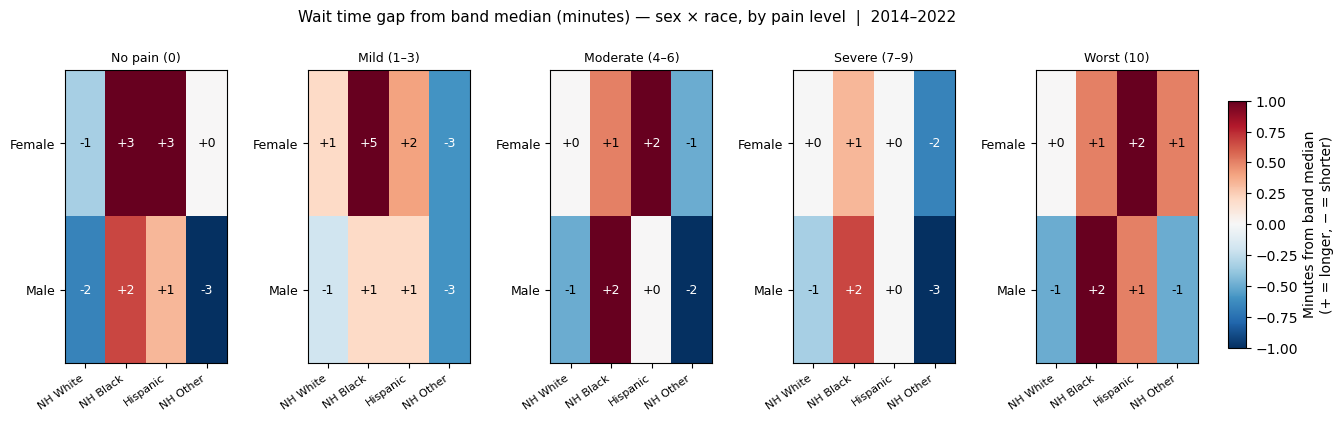

Wait time gap from band median (minutes) — sex × race intersections:

No pain (0) (band median = 15 min):
        NH White  NH Black  Hispanic  NH Other
Female      -1.0       3.0       3.0       0.0
Male        -2.0       2.0       1.0      -3.0

Mild (1–3) (band median = 16 min):
        NH White  NH Black  Hispanic  NH Other
Female       1.0       5.0       2.0      -3.0
Male        -1.0       1.0       1.0      -3.0

Moderate (4–6) (band median = 16 min):
        NH White  NH Black  Hispanic  NH Other
Female       0.0       1.0       2.0      -1.0
Male        -1.0       2.0       0.0      -2.0

Severe (7–9) (band median = 17 min):
        NH White  NH Black  Hispanic  NH Other
Female       0.0       1.0       0.0      -2.0
Male        -1.0       2.0       0.0      -3.0

Worst (10) (band median = 16 min):
        NH White  NH Black  Hispanic  NH Other
Female       0.0       1.0       2.0       1.0
Male        -1.0       2.0       1.0      -1.0


In [99]:
SEX_GROUPS  = ["Female", "Male"]
RACE_GROUPS = ["NH White", "NH Black", "Hispanic", "NH Other"]

fig, axes = plt.subplots(1, len(BAND_NAMES_12), figsize=(15, 3.8))

for ax, band in zip(axes, BAND_NAMES_12):
    sub = base12[base12["pain_band"] == band].copy()
    band_median = sub["WAITTIME"].median()

    gap_matrix = np.full((len(SEX_GROUPS), len(RACE_GROUPS)), np.nan)
    for i, sex in enumerate(SEX_GROUPS):
        for j, race in enumerate(RACE_GROUPS):
            s = sub[(sub["sex_label"] == sex) & (sub["race_label"] == race)]["WAITTIME"].dropna()
            if len(s) >= 30:
                gap_matrix[i, j] = s.median() - band_median

    vmax = np.nanmax(np.abs(gap_matrix))
    ax.imshow(gap_matrix, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(RACE_GROUPS)))
    ax.set_xticklabels(RACE_GROUPS, rotation=35, ha="right", fontsize=8)
    ax.set_yticks(range(len(SEX_GROUPS)))
    ax.set_yticklabels(SEX_GROUPS, fontsize=9)
    ax.set_title(band, fontsize=9)

    for i in range(len(SEX_GROUPS)):
        for j in range(len(RACE_GROUPS)):
            v = gap_matrix[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:+.0f}", ha="center", va="center",
                        fontsize=9, color="white" if abs(v) > vmax * 0.55 else "black")

fig.subplots_adjust(right=0.88, wspace=0.5)
cbar_ax = fig.add_axes([0.90, 0.15, 0.012, 0.65])
sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=plt.Normalize(-1, 1))
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label="Minutes from band median\n(+ = longer, − = shorter)")

fig.suptitle(
    "Wait time gap from band median (minutes) — sex × race, by pain level  |  2014–2022",
    fontsize=11, y=1.04
)
plt.show()

print("Wait time gap from band median (minutes) — sex × race intersections:")
for band in BAND_NAMES_12:
    sub = base12[base12["pain_band"] == band]
    bm = sub["WAITTIME"].median()
    rows = {}
    for sex in SEX_GROUPS:
        row = {}
        for race in RACE_GROUPS:
            s = sub[(sub["sex_label"] == sex) & (sub["race_label"] == race)]["WAITTIME"].dropna()
            row[race] = round(s.median() - bm, 1) if len(s) >= 30 else np.nan
        rows[sex] = row
    print(f"\n{band} (band median = {bm:.0f} min):")
    print(pd.DataFrame(rows).T.to_string())

### 12b. Within-pain-band gap — each group vs. the overall median for that band

Subtracting the overall median wait for each pain band isolates how much each group deviates *within* that severity level. Positive = longer wait than average; negative = shorter. This normalises out the raw pain-severity effect so only the group effect remains.

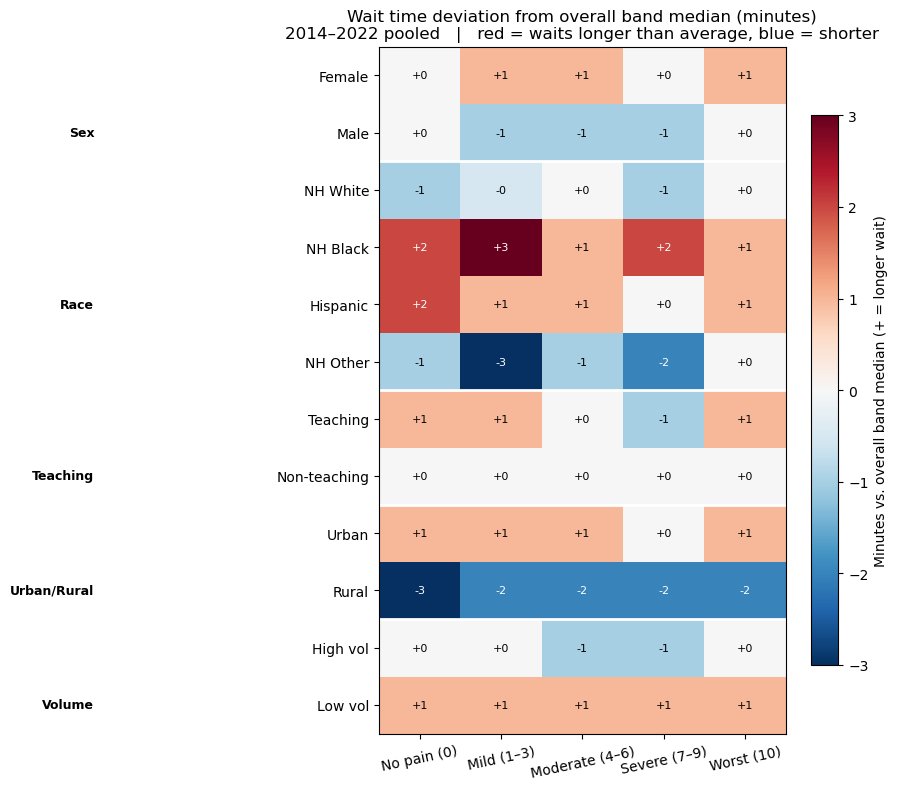

Overall band medians used as reference:
  No pain (0): 15.0 min
  Mild (1–3): 16.0 min
  Moderate (4–6): 16.0 min
  Severe (7–9): 17.0 min
  Worst (10): 16.0 min

Group deviation from band median (minutes, + = longer wait):


,No pain (0),Mild (1–3),Moderate (4–6),Severe (7–9),Worst (10)
Female,0.0,1.0,1.0,0.0,1.0
Male,0.0,-1.0,-1.0,-1.0,0.0
NH White,-1.0,-0.5,0.0,-1.0,0.0
NH Black,2.0,3.0,1.0,2.0,1.0
Hispanic,2.0,1.0,1.0,0.0,1.0
NH Other,-1.0,-3.0,-1.0,-2.0,0.0
Teaching,1.0,1.0,0.0,-1.0,1.0
Non-teaching,0.0,0.0,0.0,0.0,0.0
Urban,1.0,1.0,1.0,0.0,1.0
Rural,-3.0,-2.0,-2.0,-2.0,-2.0


In [100]:
# Overall median per pain band (reference)
overall_band_med = {
    band: base12[base12["pain_band"] == band]["WAITTIME"].median()
    for band in BAND_NAMES_12
}

# Gap matrix: group median - overall band median
gap_vals = hm_vals - np.array([overall_band_med[b] for b in BAND_NAMES_12])
gap_df = pd.DataFrame(gap_vals, index=ROW_LABELS, columns=BAND_NAMES_12)

vmax_g = np.nanmax(np.abs(gap_vals))
fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(gap_vals, cmap="RdBu_r", aspect="auto", vmin=-vmax_g, vmax=vmax_g)
plt.colorbar(im, ax=ax, label="Minutes vs. overall band median (+ = longer wait)", shrink=0.8)

ax.set_xticks(range(len(BAND_NAMES_12)))
ax.set_xticklabels(BAND_NAMES_12, rotation=12)
ax.set_yticks(range(len(ROW_LABELS)))
ax.set_yticklabels(ROW_LABELS)
ax.set_title("Wait time deviation from overall band median (minutes)\n2014–2022 pooled   |   red = waits longer than average, blue = shorter",
             fontsize=12)

for r in range(len(ROW_LABELS)):
    for c in range(len(BAND_NAMES_12)):
        v = gap_vals[r, c]
        if not np.isnan(v):
            ax.text(c, r, f"{v:+.0f}", ha="center", va="center",
                    fontsize=8, color="white" if abs(v) > vmax_g * 0.55 else "black")

cum = 0
for dim_name, (col, groups) in DIMS.items():
    cum += len(groups)
    if cum < len(ROW_LABELS):
        ax.axhline(cum - 0.5, color="white", linewidth=2)
    mid = cum - len(groups) / 2 - 0.5 + 0.5
    ax.text(-0.7, mid, dim_name, ha="right", va="center",
            fontsize=9, fontweight="bold", transform=ax.get_yaxis_transform())

plt.tight_layout()
plt.show()

print("Overall band medians used as reference:")
for b, m in overall_band_med.items():
    print(f"  {b}: {m:.1f} min")

print("\nGroup deviation from band median (minutes, + = longer wait):")
gap_df.round(1)

### 12c. Pairwise gaps within each pain band

For each dimension, the gap between the two groups (or between each race and NH White as a reference) is shown as a bar chart faceted by pain band. This makes it easy to see whether the disparity grows, shrinks, or reverses as pain severity increases.

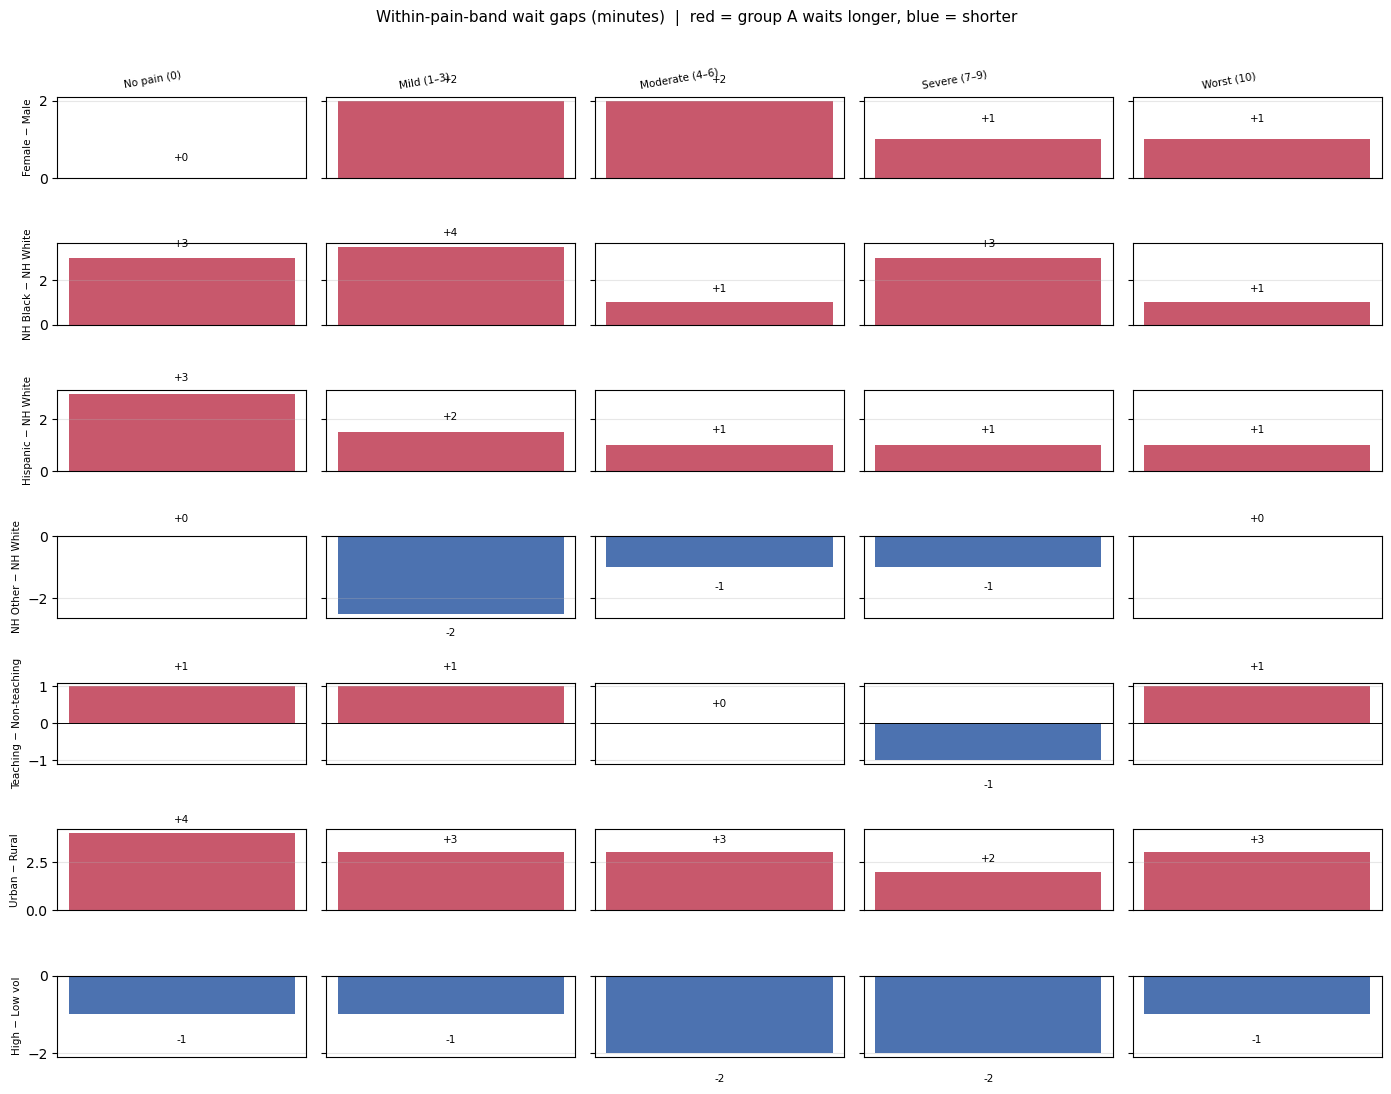

Within-pain-band pairwise gaps (minutes, positive = group A waits longer):


,No pain (0),Mild (1–3),Moderate (4–6),Severe (7–9),Worst (10)
Comparison,,,,,
Female − Male,0.0,2.0,2.0,1.0,1.0
NH Black − NH White,3.0,3.5,1.0,3.0,1.0
Hispanic − NH White,3.0,1.5,1.0,1.0,1.0
NH Other − NH White,0.0,-2.5,-1.0,-1.0,0.0
Teaching − Non-teaching,1.0,1.0,0.0,-1.0,1.0
Urban − Rural,4.0,3.0,3.0,2.0,3.0
High − Low vol,-1.0,-1.0,-2.0,-2.0,-1.0


In [101]:
PAIRWISE = [
    # (dimension label, col, group_a label, group_b label, "A − B")
    ("Sex",          "sex_label",   "Female",       "Male",          "Female − Male"),
    ("Race (vs NH White)", "race_label", "NH Black", "NH White",     "NH Black − NH White"),
    ("Race (vs NH White)", "race_label", "Hispanic",  "NH White",    "Hispanic − NH White"),
    ("Race (vs NH White)", "race_label", "NH Other",  "NH White",    "NH Other − NH White"),
    ("Teaching",     "teach_label", "Teaching",     "Non-teaching",  "Teaching − Non-teaching"),
    ("Urban/Rural",  "msa_label",   "Urban",        "Rural",         "Urban − Rural"),
    ("Volume",       "vol_label",   "High vol",     "Low vol",       "High − Low vol"),
]

# Per-band median for every (col, value) pair
def band_med(col, val, band):
    s = base12[(base12[col] == val) & (base12["pain_band"] == band)]["WAITTIME"]
    return s.median() if len(s) >= 30 else np.nan

fig, axes = plt.subplots(len(PAIRWISE), len(BAND_NAMES_12),
                          figsize=(14, len(PAIRWISE) * 1.55), sharey="row", sharex=False)

for row, (dim, col, ga, gb, label) in enumerate(PAIRWISE):
    gaps = []
    for band in BAND_NAMES_12:
        ma = band_med(col, ga, band)
        mb = band_med(col, gb, band)
        gaps.append(ma - mb if not (np.isnan(ma) or np.isnan(mb)) else np.nan)

    for col_idx, (band, gap) in enumerate(zip(BAND_NAMES_12, gaps)):
        ax = axes[row, col_idx]
        color = "#c8586c" if (not np.isnan(gap) and gap > 0) else "#4c72b0"
        ax.bar([0], [gap if not np.isnan(gap) else 0], color=color, width=0.6)
        ax.axhline(0, color="black", linewidth=0.7)
        if not np.isnan(gap):
            ax.text(0, gap + (0.4 if gap >= 0 else -0.8), f"{gap:+.0f}",
                    ha="center", va="bottom", fontsize=7.5)
        ax.set_xticks([])
        ax.grid(axis="y", alpha=0.3)
        if row == 0:
            ax.set_title(band, fontsize=7.5, rotation=10, ha="right")
        if col_idx == 0:
            ax.set_ylabel(label, fontsize=7.5, labelpad=4)

plt.suptitle("Within-pain-band wait gaps (minutes)  |  red = group A waits longer, blue = shorter",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

# Compact summary table
print("Within-pain-band pairwise gaps (minutes, positive = group A waits longer):")
rows_out = []
for dim, col, ga, gb, label in PAIRWISE:
    row_data = {"Comparison": label}
    for band in BAND_NAMES_12:
        ma = band_med(col, ga, band)
        mb = band_med(col, gb, band)
        row_data[band] = round(ma - mb, 1) if not (np.isnan(ma) or np.isnan(mb)) else np.nan
    rows_out.append(row_data)
pd.DataFrame(rows_out).set_index("Comparison")